In [39]:
# SOURCE:
# https://github.com/nflverse/nflverse-data/releases
# https://github.com/nflverse/nfldata

In [40]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from datetime import datetime
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [41]:
print(sys.path)

['C:\\Users\\Eventh\\Documents\\GitHub\\PortfolioProject\\notebooks', 'C:\\ProgramData\\anaconda3\\python311.zip', 'C:\\ProgramData\\anaconda3\\DLLs', 'C:\\ProgramData\\anaconda3\\Lib', 'C:\\ProgramData\\anaconda3', '', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\win32', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\win32\\lib', 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\Pythonwin']


In [42]:
os.getcwd()

'C:\\Users\\Eventh\\Documents\\GitHub\\PortfolioProject\\notebooks'

In [43]:
path = os.path.normpath(os.getcwd() + os.sep + os.pardir)

In [44]:
df = pd.read_csv(path + "/data/raw/games.csv", sep=",")
pd.set_option("display.max_columns", 200) # set max columns to 200, so df.head() shows all(max 200) columns
df.head()

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
0,1999_01_MIN_ATL,1999,REG,1,1999-09-12,Sunday,NaN,MIN,17.0,ATL,14.0,Home,-3.0,31.0,0.0,1999091210,598.0,NaN,199909120atl,NaN,190912001,NaN,7,7,NaN,NaN,-4.0,NaN,NaN,49.0,NaN,NaN,0,dome,astroturf,NaN,NaN,00-0003761,00-0002876,Randall Cunningham,Chris Chandler,Dennis Green,Dan Reeves,Gerry Austin,ATL00,Georgia Dome
1,1999_01_KC_CHI,1999,REG,1,1999-09-12,Sunday,NaN,KC,17.0,CHI,20.0,Home,3.0,37.0,0.0,1999091206,597.0,NaN,199909120chi,NaN,190912003,NaN,7,7,NaN,NaN,-3.0,NaN,NaN,38.0,NaN,NaN,0,outdoors,grass,80.0,12.0,00-0006300,00-0010560,Elvis Grbac,Shane Matthews,Gunther Cunningham,Dick Jauron,Phil Luckett,CHI98,Soldier Field
2,1999_01_PIT_CLE,1999,REG,1,1999-09-12,Sunday,NaN,PIT,43.0,CLE,0.0,Home,-43.0,43.0,0.0,1999091213,604.0,NaN,199909120cle,NaN,190912005,NaN,7,7,NaN,NaN,-6.0,NaN,NaN,37.0,NaN,NaN,1,outdoors,grass,78.0,12.0,00-0015700,00-0004230,Kordell Stewart,Ty Detmer,Bill Cowher,Chris Palmer,Bob McElwee,CLE00,Cleveland Browns Stadium
3,1999_01_OAK_GB,1999,REG,1,1999-09-12,Sunday,NaN,OAK,24.0,GB,28.0,Home,4.0,52.0,0.0,1999091208,602.0,NaN,199909120gnb,NaN,190912009,NaN,7,7,NaN,NaN,9.0,NaN,NaN,43.0,NaN,NaN,0,outdoors,grass,67.0,10.0,00-0005741,00-0005106,Rich Gannon,Brett Favre,Jon Gruden,Ray Rhodes,Tony Corrente,GNB00,Lambeau Field
4,1999_01_BUF_IND,1999,REG,1,1999-09-12,Sunday,NaN,BUF,14.0,IND,31.0,Home,17.0,45.0,0.0,1999091202,591.0,NaN,199909120clt,NaN,190912011,NaN,7,7,NaN,NaN,-3.0,NaN,NaN,45.5,NaN,NaN,1,dome,astroturf,NaN,NaN,00-0005363,00-0010346,Doug Flutie,Peyton Manning,Wade Phillips,Jim Mora,Ron Blum,IND99,RCA Dome


In [45]:
df.columns

Index(['game_id', 'season', 'game_type', 'week', 'gameday', 'weekday',
       'gametime', 'away_team', 'away_score', 'home_team', 'home_score',
       'location', 'result', 'total', 'overtime', 'old_game_id', 'gsis',
       'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'away_rest', 'home_rest',
       'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds',
       'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game',
       'roof', 'surface', 'temp', 'wind', 'away_qb_id', 'home_qb_id',
       'away_qb_name', 'home_qb_name', 'away_coach', 'home_coach', 'referee',
       'stadium_id', 'stadium'],
      dtype='object')

In [46]:
# Cleaning function
def clean_df(df):
    # ---------- DROP COLUMNS AND ROWS ---------- 
    # drop bet related columns
    # we also drop the scores, totals and results after creating our target "win".
    df = df.drop(columns=['away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds',
                          'home_spread_odds', 'total_line', 'under_odds', 'over_odds'])
    # drop irrelevant columns
    # overtime isnt irrelevant, but we dont have this feature for future games, so we drop it. (we could predict it too, but it's not worth)
    df = df.drop(columns=['game_id', 'old_game_id', 'gsis', 'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'overtime'])
    # drop double columns
    df = df.drop(columns=['away_qb_id', 'home_qb_id', 'stadium_id'])
    
    # all missing gametimes are in the '99 season, so just delete the season
    df = df.loc[df['season'] != 1999, :]
    df = df.reset_index(drop=True)
    
    # ---------- CREATE NEW COLUMNS ---------- 
    # check the current date
    now = datetime.now()
    # fill NaNs in gametime, so we can convert to datetime
    df["gametime"] = df["gametime"].fillna("11:11")
    # convert gameday and gametime to datetime 
    df['gameday'] = pd.to_datetime(df['gameday'])
    df['gametime'] = pd.to_datetime(df['gametime'], format="%H:%M")
    # extract hour and minute from the gametime
    df["gametime_h"] = df.loc[:, "gametime"].dt.hour
    df["gametime_min"] = df.loc[:, "gametime"].dt.minute
    # convert gametime to string only showing "HH:MM"
    df['gametime'] = df['gametime'].dt.strftime("%H:%M")
    # combine both columns to get gameday + gametime as one, so we can compare it to now
    df['datetime'] = pd.to_datetime(df['gameday'].astype(str) + ' ' + df['gametime'])
    # replace our imputation value with NaNs again
    df["gametime"] = df["gametime"].replace("11:11:00", np.nan)
    # filter rows where "datetime" is greater than "now" to drop future games
    df = df[df['datetime'] < now]
    
    # create month column
    df["month"] = df["gameday"].dt.month

    # create target column "win"
    # np.where(condition = df["result"] > 0, then = 1, else = 0)
    df["win"] = np.where(df["result"] > 0, 1, 0)
    # drop scores, totals and result
    df = df.drop(columns=["away_score", "home_score", "total", "result"])

    # ---------- IMPUTATION OF TEAMS ---------- 
    # merge old with new team names
    # OLD - NEW Team name
    # OAK (Oakland Raiders) - LV (Las Vegas Raiders) 
    # SD (San Diego Chargers) - LAC (Los Angeles Chargers)
    # STL (St. Louis Rams) - LA (Los Angeles Rams)
    team_cols = ["away_team", "home_team"]
    for col in team_cols:
        df.loc[:, col] = df.loc[:, col].replace({"OAK": "LV", 
                                                "SD": "LAC", 
                                                "STL": "LA"})
        
    # ---------- IMPUTATION OF SURFACE ---------- 
    # everything else than grass is synthetic or hybrid grass
    # combine all synthetic and hybrid under 'synthetic'
    # a_turf = astroturf
    # combine both grass
    # FUTURE: maybe dont combine all synthetic together
    df.loc[:, "surface"] = df.loc[:, "surface"].replace(["fieldturf", "astroturf", "sportturf", "matrixturf", "astroplay", "a_turf", "dessograss"], "synthetic")
    df.loc[:, "surface"] = df.loc[:, "surface"].replace("grass ", "grass")

    # get array of all stadiums that contain NaNs in surface column
    surface_nan = df.loc[df["surface"].isna(), "stadium"].unique()
    # first fill NaNs with "Unkown", so we dont get errors while using .mode() with NaNs
    df["surface"] = df["surface"].fillna("Unkown")
    for stadium in surface_nan:
        surface_mode = df.loc[df["stadium"] == stadium, "surface"].mode()[0]
        # if the mode of the surface is "Unkown", we dont have enough data for the given stadium, therefore we impute with the overall mode surface of all stadiums
        if surface_mode == "Unkown":
            df.loc[df["stadium"] == stadium, "surface"] = df["surface"].mode()[0]
        # if we have enough data for the given stadium, we impute with the mode surface of the given stadium
        else:
            df.loc[df["stadium"] == stadium, "surface"] = df["surface"].replace("Unkown", surface_mode)
    # replace "Unkown" surface with NaNs again, so its easier to spot missed imputations
    df["surface"] = df["surface"].replace("Unkown", np.nan)

    # ---------- IMPUTATION OF TEMPERATURE & WIND ---------- 
    # create crosstabs of the median value of temperate & wind for each month in each stadium for future imputation
    ct_temp = pd.crosstab(df["month"], df["stadium"], values=df["temp"], aggfunc="median", dropna=False)
    ct_wind = pd.crosstab(df["month"], df["stadium"], values=df["wind"], aggfunc="median", dropna=False) 
    # get array of all stadiums that contain NaNs in temp & wind column
    temp_nan = df.loc[df["temp"].isna(), "stadium"].unique()
    wind_nan = df.loc[df["wind"].isna(), "stadium"].unique()
    # create a set(we use set because we want to avoid duplicates) of all stadiums that have no temperature values at all
    nan_stadiums = set()
    for stadium in ct_temp.columns:
        if ct_temp.loc[:, stadium].isna().all():
            nan_stadiums.add(stadium)            
    
    # create a set(we use set because we want to avoid duplicates) of all cities that have no temperature values at all
    nan_cities = set()
    for stadium in nan_stadiums:
        cities = df.loc[(df["stadium"] == stadium) & (df["location"] == "Home"), "home_team"].unique() #take .unique() instead of .mode() because there can be multiple teams at the same stadium (e.g. SoFi Stadium = LA & LAC)
        # iterate through cities and add each unique city to the set
        for city in cities:
            nan_cities.add(city)       
    
    # iterate through the left NaNs in temp
    for stadium in temp_nan:
        # try to imputate by the monthly median temp for each stadium
        for month in df["month"].unique():
            if df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"].isna().any():
                df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"] = df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"].fillna(ct_temp.loc[month, stadium])  
        # if there are still NaNs left, imputate by the overall median temp for each stadium
        df.loc[df["stadium"] == stadium, "temp"] = df.loc[df["stadium"] == stadium, "temp"].fillna(df.loc[df["stadium"] == stadium, "temp"].median())
    
    # iterate through the left NaNs in wind  
    for stadium in wind_nan:
        # try to imputate by the monthly median wind for each stadium
        for month in df["month"].unique():
            if df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"].isna().any():
                df.loc[(df["stadium"] == stadium) & (df["month"] == month), "wind"] = df.loc[(df["stadium"] == stadium) & (df["month"] == month), "wind"].fillna(ct_wind.loc[month, stadium])   
        # if there are still NaNs left, imputate by the overall median wind for each stadium
        df.loc[df["stadium"] == stadium, "wind"] = df.loc[df["stadium"] == stadium, "wind"].fillna(df.loc[df["stadium"] == stadium, "wind"].median())
    
    # left out cities gathered by hand
    # FUTURE: web crawling
    city_temp_wind = {"DAL": [61.2, 7.8],
                      "NO": [61.2, 7.6],
                      "LV": [61.2, 6.3],
                      "TB": [61.2, 7.7],
                      "LA": [61.2, 3.5],
                      "LAC": [61.2, 3.5],
                      "DET": [61.2, 9.8],
                      "ATL": [61.2, 8.4],
                      "MIN": [61.2, 8.9],
                      "IND": [61.2, 10.84],
                      "HOU": [61.2, 7.8],
                      "BUF": [61.2, 12.3],
                      "ARI": [61.2, 4.7]}
    for city, value in city_temp_wind.items():
        df.loc[df["home_team"] == city, "temp"] = df.loc[df["home_team"] == city, "temp"].fillna(value[0])
        df.loc[df["home_team"] == city, "wind"] = df.loc[df["home_team"] == city, "wind"].fillna(value[1])
    
    # ---------- IMPUTATION OF QB's ---------- 
    # done by hand for now
    # FUTURE: web crawling
    missing_qbs = [["Russel Wilson", "Patrick Mahomes"],
               ["Lamar Jackson", "Ryan Tannehill"],
               ["Sam Howell", "Desmond Ridder"],
               ["Kirk Cousins"," Tyson Bagent"],
               ["Geno Smith", "Joe Burrow"],
               ["Derek Carr", "C.J. Stroud"],
               ["Gardner Minshew", "Trevor Lawrence"],
               ["Bryce Young", "Tua Tagovailoa"]]

    k = 0
    for i in range(6240, 6249):
        if i == 6245:
            k += 1
        df.loc[i, "away_qb_name"] = missing_qbs[i-6240-k][0]
        df.loc[i, "home_qb_name"] = missing_qbs[i-6240-k][1]
        
    # ---------- IMPUTATION OF REFEREES ---------- 
    # done by hand for now
    # FUTURE: web crawling
    # Carl Cheffers - https://www.espn.com/nfl/game?gameId=401326540&_slug_=patriots-colts
    df.loc[5802, "referee"] = "Carl Cheffers"

    # ----- IMPORTANT ------
    # maybe keep espn-id to crawl data from - https://www.espn.com/nfl/game?gameId=401326540
    # same for pfr - https://www.pro-football-reference.com/boxscores/199909120atl.htm
    #
    # https://www.ftnfantasy.com/nfl/game-logs?page=ForLogsView&teamAbbv=ATL&year=2023 - for web crawling
    # https://www.footballdb.com/games/boxscore/miami-dolphins-vs-kansas-city-chiefs-2024011302
    # https://www.footballdb.com/teams/nfl/arizona-cardinals/seasons

    return df

In [47]:
df_clean = clean_df(df)

In [48]:
df_clean.head()

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium,gametime_h,gametime_min,datetime,month,win
0,2000,REG,1,2000-09-03,Sunday,13:00,SF,28.0,ATL,36.0,Home,8.0,64.0,0.0,7,7,1,dome,synthetic,61.2,8.4,Jeff Garcia,Chris Chandler,Steve Mariucci,Dan Reeves,Walt Coleman,Georgia Dome,13,0,2000-09-03 13:00:00,9,1
1,2000,REG,1,2000-09-03,Sunday,13:00,JAX,27.0,CLE,7.0,Home,-20.0,34.0,0.0,7,7,1,outdoors,grass,78.0,6.0,Mark Brunell,Tim Couch,Tom Coughlin,Chris Palmer,Bernie Kukar,Cleveland Browns Stadium,13,0,2000-09-03 13:00:00,9,0
2,2000,REG,1,2000-09-03,Sunday,13:00,IND,27.0,KC,14.0,Home,-13.0,41.0,0.0,7,7,0,outdoors,grass,90.0,5.0,Peyton Manning,Elvis Grbac,Jim Mora,Gunther Cunningham,Larry Nemmers,Arrowhead Stadium,13,0,2000-09-03 13:00:00,9,0
3,2000,REG,1,2000-09-03,Sunday,13:00,CHI,27.0,MIN,30.0,Home,3.0,57.0,0.0,7,7,1,dome,synthetic,61.2,8.9,Cade McNown,Daunte Culpepper,Dick Jauron,Dennis Green,Ed Hochuli,Hubert H. Humphrey Metrodome,13,0,2000-09-03 13:00:00,9,1
4,2000,REG,1,2000-09-03,Sunday,13:00,TB,21.0,NE,16.0,Home,-5.0,37.0,0.0,7,7,0,outdoors,grass,71.0,5.0,Shaun King,Drew Bledsoe,Tony Dungy,Bill Belichick,Jeff Triplette,Foxboro Stadium,13,0,2000-09-03 13:00:00,9,0


In [49]:
df_clean.iloc[-6:, :]

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium,gametime_h,gametime_min,datetime,month,win
6438,2023,WC,19,2024-01-15,Monday,16:30,PIT,17.0,BUF,31.0,Home,14.0,48.0,0.0,9,8,0,outdoors,synthetic,17.0,10.0,Mason Rudolph,Josh Allen,Mike Tomlin,Sean McDermott,Carl Cheffers,New Era Field,16,30,2024-01-15 16:30:00,1,1
6439,2023,WC,19,2024-01-15,Monday,20:00,PHI,9.0,TB,32.0,Home,23.0,41.0,0.0,8,8,0,outdoors,grass,65.0,2.0,Jalen Hurts,Baker Mayfield,Nick Sirianni,Todd Bowles,Adrian Hill,Raymond James Stadium,20,0,2024-01-15 20:00:00,1,1
6440,2023,DIV,20,2024-01-20,Saturday,16:30,HOU,10.0,BAL,34.0,Home,24.0,44.0,0.0,7,14,0,outdoors,grass,27.0,16.0,C.J. Stroud,Lamar Jackson,DeMeco Ryans,John Harbaugh,John Hussey,M&T Bank Stadium,16,30,2024-01-20 16:30:00,1,1
6441,2023,DIV,20,2024-01-20,Saturday,20:15,GB,21.0,SF,24.0,Home,3.0,45.0,0.0,6,13,0,outdoors,grass,59.0,8.0,Jordan Love,Brock Purdy,Matt LaFleur,Kyle Shanahan,Alex Kemp,Levi's Stadium,20,15,2024-01-20 20:15:00,1,1
6442,2023,DIV,20,2024-01-21,Sunday,15:00,TB,23.0,DET,31.0,Home,8.0,54.0,0.0,6,7,0,dome,synthetic,61.2,9.8,Baker Mayfield,Jared Goff,Todd Bowles,Dan Campbell,NaN,Ford Field,15,0,2024-01-21 15:00:00,1,1
6443,2023,DIV,20,2024-01-21,Sunday,18:30,KC,27.0,BUF,24.0,Home,-3.0,51.0,0.0,8,6,0,outdoors,synthetic,31.0,10.0,Patrick Mahomes,Josh Allen,Andy Reid,Sean McDermott,NaN,New Era Field,18,30,2024-01-21 18:30:00,1,0


In [8]:
# drop bet related columns
df = df.drop(columns=['away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds',
       'home_spread_odds', 'total_line', 'under_odds', 'over_odds'])
# drop irrelevant columns
df = df.drop(columns=['game_id', 'old_game_id', 'gsis', 'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn'])
# drop double columns
df = df.drop(columns=['away_qb_id', 'home_qb_id', 'stadium_id'])

In [9]:
df.head()

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium
0,1999,REG,1,1999-09-12,Sunday,NaN,MIN,17.0,ATL,14.0,Home,-3.0,31.0,0.0,7,7,0,dome,astroturf,NaN,NaN,Randall Cunningham,Chris Chandler,Dennis Green,Dan Reeves,Gerry Austin,Georgia Dome
1,1999,REG,1,1999-09-12,Sunday,NaN,KC,17.0,CHI,20.0,Home,3.0,37.0,0.0,7,7,0,outdoors,grass,80.0,12.0,Elvis Grbac,Shane Matthews,Gunther Cunningham,Dick Jauron,Phil Luckett,Soldier Field
2,1999,REG,1,1999-09-12,Sunday,NaN,PIT,43.0,CLE,0.0,Home,-43.0,43.0,0.0,7,7,1,outdoors,grass,78.0,12.0,Kordell Stewart,Ty Detmer,Bill Cowher,Chris Palmer,Bob McElwee,Cleveland Browns Stadium
3,1999,REG,1,1999-09-12,Sunday,NaN,OAK,24.0,GB,28.0,Home,4.0,52.0,0.0,7,7,0,outdoors,grass,67.0,10.0,Rich Gannon,Brett Favre,Jon Gruden,Ray Rhodes,Tony Corrente,Lambeau Field
4,1999,REG,1,1999-09-12,Sunday,NaN,BUF,14.0,IND,31.0,Home,17.0,45.0,0.0,7,7,1,dome,astroturf,NaN,NaN,Doug Flutie,Peyton Manning,Wade Phillips,Jim Mora,Ron Blum,RCA Dome


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6699 entries, 0 to 6698
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   season        6699 non-null   int64  
 1   game_type     6699 non-null   object 
 2   week          6699 non-null   int64  
 3   gameday       6699 non-null   object 
 4   weekday       6699 non-null   object 
 5   gametime      6440 non-null   object 
 6   away_team     6699 non-null   object 
 7   away_score    6693 non-null   float64
 8   home_team     6699 non-null   object 
 9   home_score    6693 non-null   float64
 10  location      6699 non-null   object 
 11  result        6693 non-null   float64
 12  total         6693 non-null   float64
 13  overtime      6693 non-null   float64
 14  away_rest     6699 non-null   int64  
 15  home_rest     6699 non-null   int64  
 16  div_game      6699 non-null   int64  
 17  roof          6699 non-null   object 
 18  surface       6657 non-null 

In [11]:
df.iloc[-20:-18, :]

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium
6679,2023,REG,18,2024-01-07,Sunday,13:00,TB,9.0,CAR,0.0,Home,-9.0,9.0,0.0,7,7,1,outdoors,grass,54.0,19.0,Baker Mayfield,Bryce Young,Todd Bowles,Chris Tabor,Clete Blakeman,Bank of America Stadium
6680,2023,REG,18,2024-01-07,Sunday,13:00,CLE,14.0,CIN,31.0,Home,17.0,45.0,0.0,10,7,1,outdoors,fieldturf,38.0,12.0,Jeff Driskel,Jake Browning,Kevin Stefanski,Zac Taylor,Alan Eck,Paycor Stadium


In [12]:
print(df.loc[6679, "gametime"])

13:00


In [13]:
# convert gameday & gametime to datetime
df["gameday"] = pd.to_datetime(df["gameday"])
df["gametime"] = df["gametime"].fillna("11:11")
df["gametime"] = pd.to_datetime(df["gametime"], format="%H:%M")

In [14]:
df["gametime"] = df["gametime"].dt.strftime('%H:%M')

In [15]:
df["gametime"] = df["gametime"].replace("11:11", np.nan)

In [16]:
df.iloc[-20:-18, :]

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium
6679,2023,REG,18,2024-01-07,Sunday,13:00,TB,9.0,CAR,0.0,Home,-9.0,9.0,0.0,7,7,1,outdoors,grass,54.0,19.0,Baker Mayfield,Bryce Young,Todd Bowles,Chris Tabor,Clete Blakeman,Bank of America Stadium
6680,2023,REG,18,2024-01-07,Sunday,13:00,CLE,14.0,CIN,31.0,Home,17.0,45.0,0.0,10,7,1,outdoors,fieldturf,38.0,12.0,Jeff Driskel,Jake Browning,Kevin Stefanski,Zac Taylor,Alan Eck,Paycor Stadium


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6699 entries, 0 to 6698
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   season        6699 non-null   int64         
 1   game_type     6699 non-null   object        
 2   week          6699 non-null   int64         
 3   gameday       6699 non-null   datetime64[ns]
 4   weekday       6699 non-null   object        
 5   gametime      6440 non-null   object        
 6   away_team     6699 non-null   object        
 7   away_score    6693 non-null   float64       
 8   home_team     6699 non-null   object        
 9   home_score    6693 non-null   float64       
 10  location      6699 non-null   object        
 11  result        6693 non-null   float64       
 12  total         6693 non-null   float64       
 13  overtime      6693 non-null   float64       
 14  away_rest     6699 non-null   int64         
 15  home_rest     6699 non-null   int64   

In [18]:
# do this conversion at the end of data cleaning, because cant convert to int with NaNs 
# convert all float64 columns into int64

#for col in df.columns:
#    if df[col].dtype == "float64":
#        df = df.fillna(9999) # convert NaNs to 9999 
#        print(col, df[col].isna().sum())
#        df[col] = df[col].astype("int64")
#df = df.replace(9999, np.nan)

In [19]:
df["away_score"].dtype

dtype('float64')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6699 entries, 0 to 6698
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   season        6699 non-null   int64         
 1   game_type     6699 non-null   object        
 2   week          6699 non-null   int64         
 3   gameday       6699 non-null   datetime64[ns]
 4   weekday       6699 non-null   object        
 5   gametime      6440 non-null   object        
 6   away_team     6699 non-null   object        
 7   away_score    6693 non-null   float64       
 8   home_team     6699 non-null   object        
 9   home_score    6693 non-null   float64       
 10  location      6699 non-null   object        
 11  result        6693 non-null   float64       
 12  total         6693 non-null   float64       
 13  overtime      6693 non-null   float64       
 14  away_rest     6699 non-null   int64         
 15  home_rest     6699 non-null   int64   

In [21]:
df.isna().sum()

season             0
game_type          0
week               0
gameday            0
weekday            0
gametime         259
away_team          0
away_score         6
home_team          0
home_score         6
location           0
result             6
total              6
overtime           6
away_rest          0
home_rest          0
div_game           0
roof               0
surface           42
temp            1873
wind            1873
away_qb_name       8
home_qb_name       8
away_coach         0
home_coach         0
referee            7
stadium            0
dtype: int64

In [22]:
# for now:
# impute surface & temp & wind based on median of location
# future:
# impute data via web crawling, get temp & wind via weather website

In [23]:
df.loc[df['away_qb_name'].isna(), :]

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium
6499,2023,REG,6,2023-10-12,Thursday,20:15,DEN,8.0,KC,19.0,Home,11.0,27.0,0.0,4,4,1,outdoors,grass,NaN,NaN,NaN,NaN,Sean Payton,Andy Reid,Shawn Hochuli,GEHA Field at Arrowhead Stadium
6500,2023,REG,6,2023-10-15,Sunday,09:30,BAL,24.0,TEN,16.0,Neutral,-8.0,40.0,0.0,7,7,0,outdoors,NaN,NaN,NaN,NaN,NaN,John Harbaugh,Mike Vrabel,Bill Vinovich,Nissan Stadium
6501,2023,REG,6,2023-10-15,Sunday,13:00,WAS,24.0,ATL,16.0,Home,-8.0,40.0,0.0,10,7,0,closed,fieldturf,NaN,NaN,NaN,NaN,Ron Rivera,Arthur Smith,Clete Blakeman,Mercedes-Benz Stadium
6502,2023,REG,6,2023-10-15,Sunday,13:00,MIN,19.0,CHI,13.0,Home,-6.0,32.0,0.0,7,10,1,outdoors,grass,53.0,16.0,NaN,NaN,Kevin O'Connell,Matt Eberflus,Brad Allen,Soldier Field
6503,2023,REG,6,2023-10-15,Sunday,13:00,SEA,13.0,CIN,17.0,Home,4.0,30.0,0.0,13,7,0,outdoors,fieldturf,57.0,15.0,NaN,NaN,Pete Carroll,Zac Taylor,Adrian Hill,Paycor Stadium
6505,2023,REG,6,2023-10-15,Sunday,13:00,NO,13.0,HOU,20.0,Home,7.0,33.0,0.0,7,7,0,closed,astroturf,NaN,NaN,NaN,NaN,Dennis Allen,DeMeco Ryans,Alan Eck,NRG Stadium
6506,2023,REG,6,2023-10-15,Sunday,13:00,IND,20.0,JAX,37.0,Home,17.0,57.0,0.0,7,7,1,outdoors,grass,NaN,NaN,NaN,NaN,Shane Steichen,Doug Pederson,Alex Kemp,TIAA Bank Stadium
6507,2023,REG,6,2023-10-15,Sunday,13:00,CAR,21.0,MIA,42.0,Home,21.0,63.0,0.0,7,7,0,outdoors,grass,87.0,12.0,NaN,NaN,Frank Reich,Mike McDaniel,Craig Wrolstad,Hard Rock Stadium


In [24]:
df.loc[df['gametime'].isna(), :].groupby("season").count()

,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium
season,,,,,,,,,,,,,,,,,,,,,,,,,,
1999,259,259,259,259,0,259,259,259,259,259,259,259,259,259,259,259,259,259,197,197,259,259,259,259,259,259


In [25]:
# all missing gametimes are in the '99 season, so just delete the season
df = df.loc[df['season'] != 1999, :]
df = df.reset_index(drop=True)
df.head()

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium
0,2000,REG,1,2000-09-03,Sunday,13:00,SF,28.0,ATL,36.0,Home,8.0,64.0,0.0,7,7,1,dome,astroturf,NaN,NaN,Jeff Garcia,Chris Chandler,Steve Mariucci,Dan Reeves,Walt Coleman,Georgia Dome
1,2000,REG,1,2000-09-03,Sunday,13:00,JAX,27.0,CLE,7.0,Home,-20.0,34.0,0.0,7,7,1,outdoors,grass,78.0,6.0,Mark Brunell,Tim Couch,Tom Coughlin,Chris Palmer,Bernie Kukar,Cleveland Browns Stadium
2,2000,REG,1,2000-09-03,Sunday,13:00,IND,27.0,KC,14.0,Home,-13.0,41.0,0.0,7,7,0,outdoors,grass,90.0,5.0,Peyton Manning,Elvis Grbac,Jim Mora,Gunther Cunningham,Larry Nemmers,Arrowhead Stadium
3,2000,REG,1,2000-09-03,Sunday,13:00,CHI,27.0,MIN,30.0,Home,3.0,57.0,0.0,7,7,1,dome,astroturf,NaN,NaN,Cade McNown,Daunte Culpepper,Dick Jauron,Dennis Green,Ed Hochuli,Hubert H. Humphrey Metrodome
4,2000,REG,1,2000-09-03,Sunday,13:00,TB,21.0,NE,16.0,Home,-5.0,37.0,0.0,7,7,0,outdoors,grass,71.0,5.0,Shaun King,Drew Bledsoe,Tony Dungy,Bill Belichick,Jeff Triplette,Foxboro Stadium


In [26]:
# drop the last 6 games because they're future games
df = df.iloc[:-6, :].copy()

In [27]:
# create target column "win"
# np.where(condition = df["result"] > 0, then = 1, else = 0)
df["win"] = np.where(df["result"] > 0, 1, 0)
        
df.head()

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium,win
0,2000,REG,1,2000-09-03,Sunday,13:00,SF,28.0,ATL,36.0,Home,8.0,64.0,0.0,7,7,1,dome,astroturf,NaN,NaN,Jeff Garcia,Chris Chandler,Steve Mariucci,Dan Reeves,Walt Coleman,Georgia Dome,1
1,2000,REG,1,2000-09-03,Sunday,13:00,JAX,27.0,CLE,7.0,Home,-20.0,34.0,0.0,7,7,1,outdoors,grass,78.0,6.0,Mark Brunell,Tim Couch,Tom Coughlin,Chris Palmer,Bernie Kukar,Cleveland Browns Stadium,0
2,2000,REG,1,2000-09-03,Sunday,13:00,IND,27.0,KC,14.0,Home,-13.0,41.0,0.0,7,7,0,outdoors,grass,90.0,5.0,Peyton Manning,Elvis Grbac,Jim Mora,Gunther Cunningham,Larry Nemmers,Arrowhead Stadium,0
3,2000,REG,1,2000-09-03,Sunday,13:00,CHI,27.0,MIN,30.0,Home,3.0,57.0,0.0,7,7,1,dome,astroturf,NaN,NaN,Cade McNown,Daunte Culpepper,Dick Jauron,Dennis Green,Ed Hochuli,Hubert H. Humphrey Metrodome,1
4,2000,REG,1,2000-09-03,Sunday,13:00,TB,21.0,NE,16.0,Home,-5.0,37.0,0.0,7,7,0,outdoors,grass,71.0,5.0,Shaun King,Drew Bledsoe,Tony Dungy,Bill Belichick,Jeff Triplette,Foxboro Stadium,0


In [28]:
#df.groupby("season")["win"].value_counts()

In [29]:
for col in df.columns:
    print(df[col].value_counts(), '\n')

season
2021    285
2022    284
2023    272
2020    269
2013    267
2019    267
2018    267
2017    267
2016    267
2015    267
2014    267
2012    267
2011    267
2010    267
2009    267
2008    267
2007    267
2006    267
2005    267
2004    267
2003    267
2002    267
2001    259
2000    259
Name: count, dtype: int64 

game_type
REG    6175
WC       98
DIV      92
CON      46
SB       23
Name: count, dtype: int64 

week
16    382
15    382
1     381
17    381
2     380
14    376
12    375
13    374
3     370
11    357
4     352
5     342
10    341
6     337
8     335
7     334
9     328
18    134
19     96
20     50
21     25
22      2
Name: count, dtype: int64 

gameday
2018-12-30    16
2021-01-03    16
2016-01-03    16
2008-12-28    16
2014-12-28    16
              ..
2000-09-04     1
2013-09-26     1
2013-09-30     1
2013-10-03     1
2013-09-23     1
Name: count, Length: 1239, dtype: int64 

weekday
Sunday       5496
Monday        417
Thursday      284
Saturday      225
Friday   

In [30]:
df["away_team"].nunique()

35

In [31]:
# merge old with new team names
# OLD - NEW Team name
# OAK (Oakland Raiders) - LV (Las Vegas Raiders) 
# SD (San Diego Chargers) - LAC (Los Angeles Chargers)
# STL (St. Louis Rams) - LA (Los Angeles Rams)

team_cols = ["away_team", "home_team"]

for col in team_cols:
    df.loc[:, col] = df.loc[:, col].replace({"OAK": "LV", 
                                             "SD": "LAC", 
                                             "STL": "LA"})
    
df["home_team"].nunique()

32

In [32]:
df["surface"].value_counts()

surface
grass         3589
fieldturf     1633
astroturf      348
sportturf      294
matrixturf     168
astroplay      118
grass           93
a_turf          89
dessograss      61
Name: count, dtype: int64

In [33]:
# everything else than grass is synthetic or hybrid grass
# combine all synthetic and hybrid under 'synthetic'
# a_turf = astroturf
# combine both grass

# FUTURE:
# Maybe dont combine all synthetic together

df.loc[:, "surface"] = df.loc[:, "surface"].replace(["fieldturf", "astroturf", "sportturf", "matrixturf", "astroplay", "a_turf", "dessograss"], "synthetic")
df.loc[:, "surface"] = df.loc[:, "surface"].replace("grass ", "grass")

df["surface"].value_counts()

surface
grass        3682
synthetic    2711
Name: count, dtype: int64

In [34]:
df.isna().sum()

season             0
game_type          0
week               0
gameday            0
weekday            0
gametime           0
away_team          0
away_score         0
home_team          0
home_score         0
location           0
result             0
total              0
overtime           0
away_rest          0
home_rest          0
div_game           0
roof               0
surface           41
temp            1805
wind            1805
away_qb_name       8
home_qb_name       8
away_coach         0
home_coach         0
referee            1
stadium            0
win                0
dtype: int64

In [35]:
# impute surface based on mode in each stadium
# impute temp and wind, based on historical median in that month 
# impute missing qb's and referess by hand, in the future we do this via web crawling

In [36]:
df.describe()

,season,week,gameday,away_score,home_score,result,total,overtime,away_rest,home_rest,div_game,temp,wind,win
count,6434.000000,6434.000000,6434,6434.000000,6434.000000,6434.000000,6434.000000,6434.000000,6434.000000,6434.000000,6434.000000,4629.000000,4629.000000,6434.000000
mean,2011.593255,9.550513,2012-06-12 19:52:41.330432,20.940783,23.254896,2.314113,44.195679,0.062014,7.482126,7.513522,0.374106,57.791316,8.499028,0.563258
min,2000.000000,1.000000,2000-09-03 00:00:00,0.000000,0.000000,-49.000000,3.000000,0.000000,4.000000,4.000000,0.000000,-6.000000,0.000000,0.000000
25%,2006.000000,5.000000,2006-09-17 00:00:00,14.000000,16.000000,-7.000000,34.000000,0.000000,7.000000,7.000000,0.000000,46.000000,5.000000,0.000000
50%,2012.000000,10.000000,2012-09-16 00:00:00,20.000000,23.000000,3.000000,43.000000,0.000000,7.000000,7.000000,0.000000,59.000000,8.000000,1.000000
75%,2018.000000,14.000000,2018-09-23 00:00:00,27.000000,30.000000,11.000000,53.000000,0.000000,7.000000,7.000000,1.000000,71.000000,12.000000,1.000000
max,2023.000000,22.000000,2024-01-07 00:00:00,59.000000,70.000000,59.000000,106.000000,1.000000,21.000000,16.000000,1.000000,109.000000,71.000000,1.000000
std,6.934646,5.306904,NaN,10.056536,10.318494,14.626306,14.187375,0.241200,1.995271,2.094359,0.483929,17.045407,5.403615,0.496021


In [37]:
# we can see that the average HOME_SCORE is higher than the average AWAY_SCORE, so home_teams have a slight advantage

In [38]:
#sns.pairplot(df)

In [39]:
# wind [mph] - 71 mph x 1.609 = 114.263 kmh
# temp [°F] - (109 °F − 32) × 5/9 = 42.778 °C
# web crawling for weather: https://www.wunderground.com/history

In [40]:
df.loc[df["surface"].isna(), "stadium"].value_counts()

stadium
Tottenham Stadium                  2
Acrisure Stadium                   2
Nissan Stadium                     2
TIAA Bank Stadium                  2
New Era Field                      2
MetLife Stadium                    2
Gillette Stadium                   2
SoFi Stadium                       2
Empower Field at Mile High         2
Mercedes-Benz Stadium              2
Lucas Oil Stadium                  1
Azteca Stadium                     1
AT&T Stadium                       1
State Farm Stadium                 1
Wembley Stadium                    1
Raymond James Stadium              1
Allianz Arena                      1
NRG Stadium                        1
Ford Field                         1
Paycor Stadium                     1
Lincoln Financial Field            1
U.S. Bank Stadium                  1
GEHA Field at Arrowhead Stadium    1
Lumen Field                        1
M&T Bank Stadium                   1
Levi's Stadium                     1
Soldier Field                 

In [41]:
df.loc[df["stadium"] == "Tottenham Stadium", :]

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium,win
5126,2019,REG,5,2019-10-06,Sunday,13:00,CHI,21.0,LV,24.0,Neutral,3.0,45.0,0.0,7,7,0,outdoors,grass,59.0,15.0,Chase Daniel,Derek Carr,Matt Nagy,Jon Gruden,Tony Corrente,Tottenham Stadium,1
5136,2019,REG,6,2019-10-13,Sunday,09:30,CAR,37.0,TB,26.0,Neutral,-11.0,63.0,0.0,7,7,1,outdoors,grass,61.0,14.0,Kyle Allen,Jameis Winston,Ron Rivera,Bruce Arians,Walt Anderson,Tottenham Stadium,0
5658,2021,REG,5,2021-10-10,Sunday,09:30,NYJ,20.0,ATL,27.0,Neutral,7.0,47.0,0.0,7,7,0,outdoors,grass,63.0,8.0,Zach Wilson,Matt Ryan,Robert Saleh,Arthur Smith,Tony Corrente,Tottenham Stadium,1
5674,2021,REG,6,2021-10-17,Sunday,09:30,MIA,20.0,JAX,23.0,Neutral,3.0,43.0,0.0,7,7,0,outdoors,grass,63.0,11.0,Tua Tagovailoa,Trevor Lawrence,Brian Flores,Urban Meyer,John Hussey,Tottenham Stadium,1
5927,2022,REG,4,2022-10-02,Sunday,09:30,MIN,28.0,NO,25.0,Neutral,-3.0,53.0,0.0,7,7,0,outdoors,NaN,NaN,NaN,Kirk Cousins,Andy Dalton,Kevin O'Connell,Dennis Allen,Clete Blakeman,Tottenham Stadium,0
5943,2022,REG,5,2022-10-09,Sunday,09:30,NYG,27.0,GB,22.0,Neutral,-5.0,49.0,0.0,7,7,0,outdoors,NaN,NaN,NaN,Daniel Jones,Aaron Rodgers,Brian Daboll,Matt LaFleur,Alex Kemp,Tottenham Stadium,0


In [42]:
# imputate surface by usual surface of the stadium
# if we have a unique stadium like "Allianz Arena" we will just use the mode value surface

In [43]:
# get array of all stadiums that contain NaNs in surface column
surface_nan = df.loc[df["surface"].isna(), "stadium"].unique()

In [44]:
# first fill NaNs with "Unkown", so we dont get errors while using .mode() with NaNs
df["surface"] = df["surface"].fillna("Unkown")

for stadium in surface_nan:
    surface_mode = df.loc[df["stadium"] == stadium, "surface"].mode()[0]
    # if the mode of the surface is "Unkown", we dont have enough data for the given stadium, therefore we impute with the overall mode surface of all stadiums
    if surface_mode == "Unkown":
        df.loc[df["stadium"] == stadium, "surface"] = df["surface"].mode()[0]
    # if we have enough data for the given stadium, we impute with the mode surface of the given stadium
    else:
        df.loc[df["stadium"] == stadium, "surface"] = df["surface"].replace("Unkown", surface_mode)

# replace "Unkown" surface with NaNs again, so its easier to spot missed imputations
df["surface"] = df["surface"].replace("Unkown", np.nan)

In [45]:
# imputate temp & wind, based on historical data at the location in the same months
# to achieve that we have do add month as a column

In [46]:
df["month"] = df["gameday"].dt.month

In [47]:
ct_temp = pd.crosstab(df["month"], df["stadium"], values=df["temp"], aggfunc="median", dropna=False)
ct_wind = pd.crosstab(df["month"], df["stadium"], values=df["wind"], aggfunc="median", dropna=False)    
ct_temp

stadium,3Com Park,AT&T Stadium,Acrisure Stadium,Adelphia Coliseum,Alamo Dome,Allegiant Stadium,Allianz Arena,Alltel Stadium,Arrowhead Stadium,Azteca Stadium,Bank of America Stadium,Candlestick Park,CenturyLink Field,Cleveland Browns Stadium,Cowboys Stadium,Dolphin Stadium,Dome at America's Center,Edward Jones Dome,Empower Field at Mile High,Ericsson Stadium,EverBank Field,FedExField,FirstEnergy Stadium,Ford Field,Foxboro Stadium,GEHA Field at Arrowhead Stadium,Georgia Dome,Giants Stadium,Gillette Stadium,Hard Rock Stadium,Heinz Field,Hubert H. Humphrey Metrodome,Husky Stadium,Invesco Field at Mile High,Jacksonville Municipal Stadium,LP Field,Lambeau Field,Levi's Stadium,Lincoln Financial Field,Los Angeles Memorial Coliseum,Louisiana Superdome,Lucas Oil Stadium,Lumen Field,M&T Bank Stadium,Mall of America Field,McAfee Coliseum,Memorial Stadium (Champaign),Mercedes-Benz Stadium,Mercedes-Benz Superdome,MetLife Stadium,Mile High Stadium,Monster Park,NRG Stadium,Network Associates Coliseum,New Era Field,New Meadowlands Stadium,Nissan Stadium,O.co Coliseum,Oakland-Alameda County Coliseum,PSINet Stadium,Paul Brown Stadium,Paycor Stadium,Pontiac Silverdome,Pro Player Stadium,Qualcomm Stadium,Qwest Field,RCA Dome,Ralph Wilson Stadium,Ravens Stadium,Raymond James Stadium,Reliant Stadium,Ring Central Coliseum,Rogers Centre,Seahawks Stadium,SoFi Stadium,Soldier Field,Sports Authority Field at Mile High,State Farm Stadium,StubHub Center,Sun Devil Stadium,Sun Life Stadium,TCF Bank Stadium,TIAA Bank Stadium,TWA Dome,Texas Stadium,The Coliseum,Three Rivers Stadium,Tiger Stadium (LSU),Tottenham Stadium,Twickenham Stadium,U.S. Bank Stadium,University of Phoenix Stadium,Veterans Stadium,Wembley Stadium
month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,53.0,NaN,36.0,42.5,NaN,NaN,NaN,69.0,34.0,NaN,52.5,50.5,48.0,32.0,NaN,69.5,NaN,NaN,43.0,49.5,61.5,48.0,38.0,NaN,25.0,35.5,NaN,35.0,33.0,75.0,27.5,NaN,49.0,36.0,NaN,53.0,26.0,55.0,40.0,59.0,NaN,NaN,42.0,50.0,NaN,48.0,NaN,NaN,NaN,44.0,NaN,56.0,NaN,55.5,32.0,48.0,41.0,56.0,54.0,36.0,39.5,38.0,NaN,70.0,59.0,44.0,NaN,35.0,NaN,65.0,NaN,NaN,NaN,NaN,NaN,32.0,42.0,NaN,NaN,63.0,79.0,-6.0,56.0,NaN,67.0,48.0,NaN,NaN,NaN,NaN,NaN,NaN,29.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,66.5,NaN,NaN,80.5,NaN,NaN,NaN,82.0,71.0,NaN,80.5,68.0,64.5,71.0,NaN,87.0,NaN,NaN,82.0,72.0,86.0,73.5,70.0,NaN,70.5,84.5,NaN,76.0,70.0,89.0,70.5,NaN,65.0,75.0,86.0,76.0,66.5,72.0,76.0,82.5,NaN,NaN,61.5,75.0,NaN,68.5,69.0,NaN,NaN,72.0,60.0,65.5,NaN,73.0,67.0,68.5,80.0,71.5,71.0,82.0,74.0,74.0,NaN,87.5,74.0,61.0,NaN,66.0,74.5,88.0,NaN,69.0,NaN,62.5,NaN,70.0,83.0,NaN,81.0,99.0,87.0,71.0,84.0,NaN,81.0,75.0,67.5,NaN,NaN,NaN,NaN,NaN,77.0,70.0
10,65.5,NaN,55.5,72.0,NaN,NaN,NaN,78.5,62.5,66.0,69.5,64.0,56.5,56.0,NaN,85.0,NaN,NaN,72.0,71.0,73.0,67.0,58.5,NaN,59.0,74.0,NaN,57.0,58.0,86.0,57.0,NaN,50.0,60.5,75.0,67.0,54.0,74.5,63.0,80.0,NaN,NaN,54.0,65.0,NaN,64.0,46.0,NaN,NaN,61.5,69.5,63.0,NaN,66.0,58.0,61.0,67.5,71.0,68.0,54.0,61.0,57.0,NaN,85.0,69.0,56.0,NaN,53.5,58.5,82.0,NaN,NaN,NaN,63.0,NaN,56.0,66.0,NaN,75.0,81.0,84.0,53.5,78.0,NaN,71.0,68.0,68.0,76.0,62.0,55.0,NaN,NaN,53.0,59.0
11,58.0,NaN,38.5,56.0,NaN,NaN,NaN,69.0,52.0,66.0,59.5,62.0,50.5,46.0,NaN,80.0,NaN,NaN,53.0,59.0,75.0,51.0,45.5,NaN,47.0,45.0,NaN,53.0,45.0,81.0,50.0,NaN,48.0,47.0,69.0,60.5,38.5,63.5,52.0,70.0,NaN,NaN,46.0,54.0,NaN,61.0,45.0,NaN,NaN,50.0,29.5,61.0,NaN,61.0,42.0,44.5,56.0,62.0,61.0,54.0,48.0,53.5,NaN,79.0,69.0,48.0,NaN,49.0,59.5,77.0,NaN,71.0,NaN,47.5,NaN,46.5,50.5,NaN,75.0,75.0,78.0,49.0,72.0,NaN,62.0,56.0,41.0,85.0,NaN,NaN,NaN,NaN,51.0,50.0
12,55.0,NaN,42.0,40.5,NaN,NaN,NaN,5

In [48]:
ct_temp.loc[:, "AT&T Stadium"].isna().all()

True

In [49]:
# create a set(we use set because we want to avoid duplicates) of all stadiums that have no temperature values at all
nan_stadiums = set()
for stadium in ct_temp.columns:
    if ct_temp.loc[:, stadium].isna().all():
        nan_stadiums.add(stadium)
        
nan_stadiums = list(nan_stadiums)
nan_stadiums

['TWA Dome',
 'Edward Jones Dome',
 'RCA Dome',
 'Lucas Oil Stadium',
 'Mercedes-Benz Superdome',
 'NRG Stadium',
 'Hubert H. Humphrey Metrodome',
 'SoFi Stadium',
 'Cowboys Stadium',
 'Alamo Dome',
 "Dome at America's Center",
 'Allegiant Stadium',
 'Rogers Centre',
 'Pontiac Silverdome',
 'Allianz Arena',
 'University of Phoenix Stadium',
 'Georgia Dome',
 'Mall of America Field',
 'Louisiana Superdome',
 'Reliant Stadium',
 'AT&T Stadium',
 'U.S. Bank Stadium',
 'Ford Field',
 'State Farm Stadium',
 'Mercedes-Benz Stadium']

In [50]:
# create a set(we use set because we want to avoid duplicates) of all cities that have no temperature values at all
nan_cities = set()
for stadium in nan_stadiums:
    cities = df.loc[(df["stadium"] == stadium) & (df["location"] == "Home"), "home_team"].unique() #take .unique() instead of .mode() because there can be multiple teams at the same stadium (e.g. SoFi Stadium = LA & LAC)
    # iterate through cities and add each unique city to the set
    for city in cities:
        nan_cities.add(city)

    
nan_cities = list(nan_cities)
nan_cities

['NO',
 'HOU',
 'ATL',
 'DAL',
 'LV',
 'BUF',
 'ARI',
 'LA',
 'MIN',
 'LAC',
 'IND',
 'DET']

In [51]:
# for the baseline-model imputate weather data by hand
# looking for data at: https://www.wunderground.com/history/monthly/us/tx/dallas/date/2020-11
# we will use the average temperate of 2020-11 at the given state

In [52]:
# CITY = AVG. TEMP @ 2020-11 
# DAL = 61.2 
# NO = 66.8 
# LV = 59.6 
# LA = 60.4 
# LAC = 60.4 
# DET = 46.1 
# ATL = 58 
# MIN = 38 
# IND = 47.5 
# HOU = 68.1 
# BUF = 46.7 
# ARI = 67.6 


In [53]:
city_temps = {"DAL": [61.2, 7.8],
              "NO": [61.2, 7.6],
              "LV": [61.2, 6.3],
              "TB": [61.2, 7.7],
              "LA": [61.2, 3.5],
              "LAC": [61.2, 3.5],
              "DET": [61.2, 9.8],
              "ATL": [61.2, 8.4],
              "MIN": [61.2, 8.9],
              "IND": [61.2, 10.84],
              "HOU": [61.2, 7.8],
              "BUF": [61.2, 12.3],
              "ARI": [61.2, 4.7]}

In [54]:
for city, value in city_temps.items():
    df.loc[df["home_team"] == city, "temp"] = df.loc[df["home_team"] == city, "temp"].fillna(value[0])
    df.loc[df["home_team"] == city, "wind"] = df.loc[df["home_team"] == city, "wind"].fillna(value[1])

In [55]:
df.isna().sum()

season            0
game_type         0
week              0
gameday           0
weekday           0
gametime          0
away_team         0
away_score        0
home_team         0
home_score        0
location          0
result            0
total             0
overtime          0
away_rest         0
home_rest         0
div_game          0
roof              0
surface           0
temp            119
wind            119
away_qb_name      8
home_qb_name      8
away_coach        0
home_coach        0
referee           1
stadium           0
win               0
month             0
dtype: int64

In [56]:
# get array of all stadiums that contain NaNs in temp & wind column
temp_nan = df.loc[df["temp"].isna(), "stadium"].unique()
wind_nan = df.loc[df["wind"].isna(), "stadium"].unique()
# check if temp_nan and wind_nan contain the same stadiums
#temp_nan == temp_nan
# both contain the same stadiums, so we could use only one variable
# BUT to prevent error in the future, we iterate through both variables, because its not guaranteed that they will always be equal

In [57]:
ct_temp

stadium,3Com Park,AT&T Stadium,Acrisure Stadium,Adelphia Coliseum,Alamo Dome,Allegiant Stadium,Allianz Arena,Alltel Stadium,Arrowhead Stadium,Azteca Stadium,Bank of America Stadium,Candlestick Park,CenturyLink Field,Cleveland Browns Stadium,Cowboys Stadium,Dolphin Stadium,Dome at America's Center,Edward Jones Dome,Empower Field at Mile High,Ericsson Stadium,EverBank Field,FedExField,FirstEnergy Stadium,Ford Field,Foxboro Stadium,GEHA Field at Arrowhead Stadium,Georgia Dome,Giants Stadium,Gillette Stadium,Hard Rock Stadium,Heinz Field,Hubert H. Humphrey Metrodome,Husky Stadium,Invesco Field at Mile High,Jacksonville Municipal Stadium,LP Field,Lambeau Field,Levi's Stadium,Lincoln Financial Field,Los Angeles Memorial Coliseum,Louisiana Superdome,Lucas Oil Stadium,Lumen Field,M&T Bank Stadium,Mall of America Field,McAfee Coliseum,Memorial Stadium (Champaign),Mercedes-Benz Stadium,Mercedes-Benz Superdome,MetLife Stadium,Mile High Stadium,Monster Park,NRG Stadium,Network Associates Coliseum,New Era Field,New Meadowlands Stadium,Nissan Stadium,O.co Coliseum,Oakland-Alameda County Coliseum,PSINet Stadium,Paul Brown Stadium,Paycor Stadium,Pontiac Silverdome,Pro Player Stadium,Qualcomm Stadium,Qwest Field,RCA Dome,Ralph Wilson Stadium,Ravens Stadium,Raymond James Stadium,Reliant Stadium,Ring Central Coliseum,Rogers Centre,Seahawks Stadium,SoFi Stadium,Soldier Field,Sports Authority Field at Mile High,State Farm Stadium,StubHub Center,Sun Devil Stadium,Sun Life Stadium,TCF Bank Stadium,TIAA Bank Stadium,TWA Dome,Texas Stadium,The Coliseum,Three Rivers Stadium,Tiger Stadium (LSU),Tottenham Stadium,Twickenham Stadium,U.S. Bank Stadium,University of Phoenix Stadium,Veterans Stadium,Wembley Stadium
month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,53.0,NaN,36.0,42.5,NaN,NaN,NaN,69.0,34.0,NaN,52.5,50.5,48.0,32.0,NaN,69.5,NaN,NaN,43.0,49.5,61.5,48.0,38.0,NaN,25.0,35.5,NaN,35.0,33.0,75.0,27.5,NaN,49.0,36.0,NaN,53.0,26.0,55.0,40.0,59.0,NaN,NaN,42.0,50.0,NaN,48.0,NaN,NaN,NaN,44.0,NaN,56.0,NaN,55.5,32.0,48.0,41.0,56.0,54.0,36.0,39.5,38.0,NaN,70.0,59.0,44.0,NaN,35.0,NaN,65.0,NaN,NaN,NaN,NaN,NaN,32.0,42.0,NaN,NaN,63.0,79.0,-6.0,56.0,NaN,67.0,48.0,NaN,NaN,NaN,NaN,NaN,NaN,29.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,66.5,NaN,NaN,80.5,NaN,NaN,NaN,82.0,71.0,NaN,80.5,68.0,64.5,71.0,NaN,87.0,NaN,NaN,82.0,72.0,86.0,73.5,70.0,NaN,70.5,84.5,NaN,76.0,70.0,89.0,70.5,NaN,65.0,75.0,86.0,76.0,66.5,72.0,76.0,82.5,NaN,NaN,61.5,75.0,NaN,68.5,69.0,NaN,NaN,72.0,60.0,65.5,NaN,73.0,67.0,68.5,80.0,71.5,71.0,82.0,74.0,74.0,NaN,87.5,74.0,61.0,NaN,66.0,74.5,88.0,NaN,69.0,NaN,62.5,NaN,70.0,83.0,NaN,81.0,99.0,87.0,71.0,84.0,NaN,81.0,75.0,67.5,NaN,NaN,NaN,NaN,NaN,77.0,70.0
10,65.5,NaN,55.5,72.0,NaN,NaN,NaN,78.5,62.5,66.0,69.5,64.0,56.5,56.0,NaN,85.0,NaN,NaN,72.0,71.0,73.0,67.0,58.5,NaN,59.0,74.0,NaN,57.0,58.0,86.0,57.0,NaN,50.0,60.5,75.0,67.0,54.0,74.5,63.0,80.0,NaN,NaN,54.0,65.0,NaN,64.0,46.0,NaN,NaN,61.5,69.5,63.0,NaN,66.0,58.0,61.0,67.5,71.0,68.0,54.0,61.0,57.0,NaN,85.0,69.0,56.0,NaN,53.5,58.5,82.0,NaN,NaN,NaN,63.0,NaN,56.0,66.0,NaN,75.0,81.0,84.0,53.5,78.0,NaN,71.0,68.0,68.0,76.0,62.0,55.0,NaN,NaN,53.0,59.0
11,58.0,NaN,38.5,56.0,NaN,NaN,NaN,69.0,52.0,66.0,59.5,62.0,50.5,46.0,NaN,80.0,NaN,NaN,53.0,59.0,75.0,51.0,45.5,NaN,47.0,45.0,NaN,53.0,45.0,81.0,50.0,NaN,48.0,47.0,69.0,60.5,38.5,63.5,52.0,70.0,NaN,NaN,46.0,54.0,NaN,61.0,45.0,NaN,NaN,50.0,29.5,61.0,NaN,61.0,42.0,44.5,56.0,62.0,61.0,54.0,48.0,53.5,NaN,79.0,69.0,48.0,NaN,49.0,59.5,77.0,NaN,71.0,NaN,47.5,NaN,46.5,50.5,NaN,75.0,75.0,78.0,49.0,72.0,NaN,62.0,56.0,41.0,85.0,NaN,NaN,NaN,NaN,51.0,50.0
12,55.0,NaN,42.0,40.5,NaN,NaN,NaN,5

In [58]:
# later use: ct_temp, ct_wind
# iterate through the left NaNs in temp
for stadium in temp_nan:
    # try to imputate by the monthly median temp for each stadium
    for month in df["month"].unique():
        if df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"].isna().any():
            df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"] = df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"].fillna(ct_temp.loc[month, stadium])  
    # if there are still NaNs left, imputate by the overall median temp for each stadium
    df.loc[df["stadium"] == stadium, "temp"] = df.loc[df["stadium"] == stadium, "temp"].fillna(df.loc[df["stadium"] == stadium, "temp"].median())

    # iterate through the left NaNs in wind  
for stadium in wind_nan:
    # try to imputate by the monthly median wind for each stadium
    for month in df["month"].unique():
        if df.loc[(df["stadium"] == stadium) & (df["month"] == month), "temp"].isna().any():
            df.loc[(df["stadium"] == stadium) & (df["month"] == month), "wind"] = df.loc[(df["stadium"] == stadium) & (df["month"] == month), "wind"].fillna(ct_wind.loc[month, stadium])   
    # if there are still NaNs left, imputate by the overall median wind for each stadium
    df.loc[df["stadium"] == stadium, "wind"] = df.loc[df["stadium"] == stadium, "wind"].fillna(df.loc[df["stadium"] == stadium, "wind"].median())

In [59]:
df.isna().sum()

season          0
game_type       0
week            0
gameday         0
weekday         0
gametime        0
away_team       0
away_score      0
home_team       0
home_score      0
location        0
result          0
total           0
overtime        0
away_rest       0
home_rest       0
div_game        0
roof            0
surface         0
temp            0
wind            0
away_qb_name    8
home_qb_name    8
away_coach      0
home_coach      0
referee         1
stadium         0
win             0
month           0
dtype: int64

In [60]:
# imputate the missing qb's and the 1 referee by hand | in the future find a way to crawl the data - https://www.nfl.com/games/patriots-at-colts-2021-reg-15
# DEN @ KC  : Russel Wilson @ Patrick Mahomes
# BAL @ TEN : Lamar Jackson @ Ryan Tannehill
# WAS @ ATL : Sam Howell @ Desmond Ridder
# MIN @ CHI : Kirk Cousins @ Tyson Bagent
# SEA @ CIN : Geno Smith @ Joe Burrow
# NO @ HOU  : Derek Carr @ C.J. Stroud
# IND @ JAX : Gardner Minshew @ Trevor Lawrence
# CAR @ MIA : Bryce Young @ Tua Tagovailoa

In [61]:
missing_qbs = [["Russel Wilson", "Patrick Mahomes"],
               ["Lamar Jackson", "Ryan Tannehill"],
               ["Sam Howell", "Desmond Ridder"],
               ["Kirk Cousins"," Tyson Bagent"],
               ["Geno Smith", "Joe Burrow"],
               ["Derek Carr", "C.J. Stroud"],
               ["Gardner Minshew", "Trevor Lawrence"],
               ["Bryce Young", "Tua Tagovailoa"]]

In [62]:
k = 0
for i in range(6240, 6249):
    if i == 6245:
        k += 1
        continue
    df.loc[i, "away_qb_name"] = missing_qbs[i-6240-k][0]
    df.loc[i, "home_qb_name"] = missing_qbs[i-6240-k][1]

In [63]:
df.loc[df["referee"].isna(), :]

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium,win,month
5802,2021,REG,15,2021-12-18,Saturday,20:20,NE,17.0,IND,27.0,Home,10.0,44.0,0.0,13,14,0,closed,synthetic,61.2,10.84,Mac Jones,Carson Wentz,Bill Belichick,Frank Reich,NaN,Lucas Oil Stadium,1,12


In [64]:
# Carl Cheffers - https://www.espn.com/nfl/game?gameId=401326540&_slug_=patriots-colts
df.loc[5802, "referee"] = "Carl Cheffers"

In [65]:
# ----- IMPORTANT ------
# maybe keep espn-id to crawl data from - https://www.espn.com/nfl/game?gameId=401326540
# same for pfr - https://www.pro-football-reference.com/boxscores/199909120atl.htm
#
# https://www.ftnfantasy.com/nfl/game-logs?page=ForLogsView&teamAbbv=ATL&year=2023 - for web crawling
# https://www.footballdb.com/games/boxscore/miami-dolphins-vs-kansas-city-chiefs-2024011302
# https://www.footballdb.com/teams/nfl/arizona-cardinals/seasons

In [66]:
df.isna().sum().sum()

0

In [67]:
# split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

<Axes: >

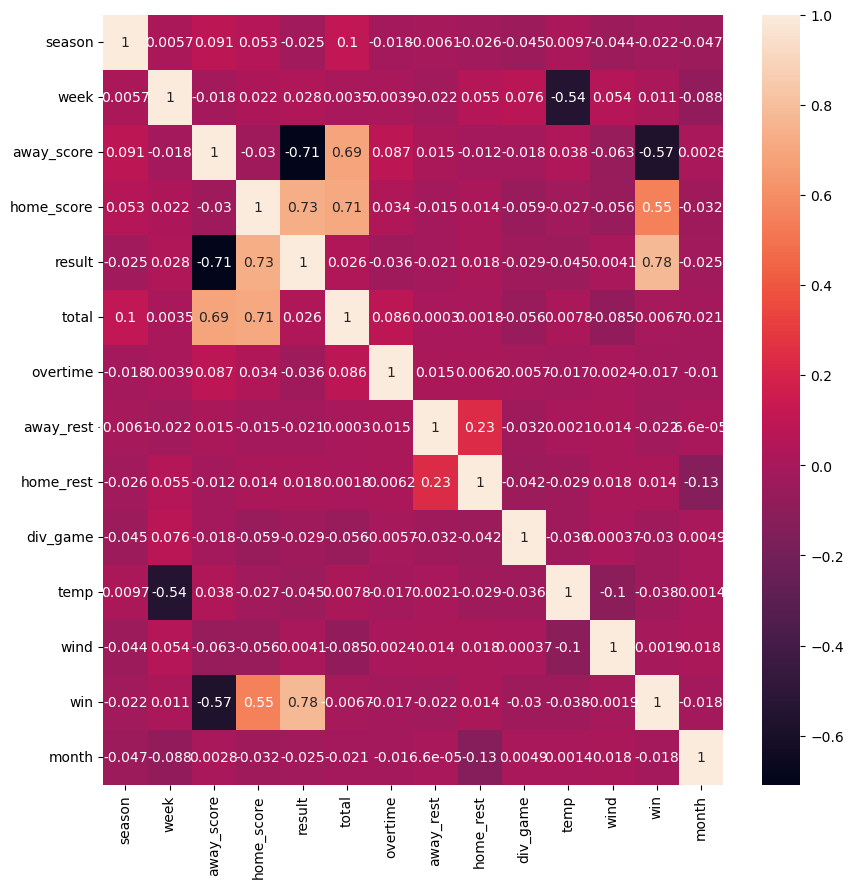

In [68]:
fig, ax = plt.subplots(figsize=(10,10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, ax=ax)

In [69]:
# for the future:
# function to display win percentage by chosen type and value
# e.g. Type = team (columns = away_team & home_team), value = "IND" shows win percantage of the Indianapolis Colts

In [70]:
df.groupby("win")["season"].count()

win
0    2810
1    3624
Name: season, dtype: int64

In [71]:
# away_points home_points
#print(df.loc[df["away_team"] == "SF", "away_score"].mean())
#df.loc[df["home_team"] == "SF", "home_score"].mean()
df.loc[df["home_team"] == "SF", "away_score"].mean()

#df.groupby("away_team")["away_score"].mean()
#df.groupby("home_team")["home_score"].mean()

20.207920792079207

In [72]:
# split into train & test set
df_train = df.loc[df["season"] < 2020, :]
df_test = df.loc[df["season"] >= 2020, :]

In [73]:
df_train.head()

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium,win,month
0,2000,REG,1,2000-09-03,Sunday,13:00,SF,28.0,ATL,36.0,Home,8.0,64.0,0.0,7,7,1,dome,synthetic,61.2,8.4,Jeff Garcia,Chris Chandler,Steve Mariucci,Dan Reeves,Walt Coleman,Georgia Dome,1,9
1,2000,REG,1,2000-09-03,Sunday,13:00,JAX,27.0,CLE,7.0,Home,-20.0,34.0,0.0,7,7,1,outdoors,grass,78.0,6.0,Mark Brunell,Tim Couch,Tom Coughlin,Chris Palmer,Bernie Kukar,Cleveland Browns Stadium,0,9
2,2000,REG,1,2000-09-03,Sunday,13:00,IND,27.0,KC,14.0,Home,-13.0,41.0,0.0,7,7,0,outdoors,grass,90.0,5.0,Peyton Manning,Elvis Grbac,Jim Mora,Gunther Cunningham,Larry Nemmers,Arrowhead Stadium,0,9
3,2000,REG,1,2000-09-03,Sunday,13:00,CHI,27.0,MIN,30.0,Home,3.0,57.0,0.0,7,7,1,dome,synthetic,61.2,8.9,Cade McNown,Daunte Culpepper,Dick Jauron,Dennis Green,Ed Hochuli,Hubert H. Humphrey Metrodome,1,9
4,2000,REG,1,2000-09-03,Sunday,13:00,TB,21.0,NE,16.0,Home,-5.0,37.0,0.0,7,7,0,outdoors,grass,71.0,5.0,Shaun King,Drew Bledsoe,Tony Dungy,Bill Belichick,Jeff Triplette,Foxboro Stadium,0,9


In [74]:
# convert gametime to datetime, so we can extract HH:MM. Maybe its easier to convert 20:30 to 2030???
df["gametime"] = pd.to_datetime(df["gametime"])
df["gametime_h"] = df.loc[:, "gametime"].dt.hour
df["gametime_min"] = df.loc[:, "gametime"].dt.minute

C:\Users\Eventh\AppData\Local\Temp\ipykernel_4816\2567460530.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["gametime"] = pd.to_datetime(df["gametime"])


In [75]:
df.head()

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium,win,month,gametime_h,gametime_min
0,2000,REG,1,2000-09-03,Sunday,2024-01-19 13:00:00,SF,28.0,ATL,36.0,Home,8.0,64.0,0.0,7,7,1,dome,synthetic,61.2,8.4,Jeff Garcia,Chris Chandler,Steve Mariucci,Dan Reeves,Walt Coleman,Georgia Dome,1,9,13,0
1,2000,REG,1,2000-09-03,Sunday,2024-01-19 13:00:00,JAX,27.0,CLE,7.0,Home,-20.0,34.0,0.0,7,7,1,outdoors,grass,78.0,6.0,Mark Brunell,Tim Couch,Tom Coughlin,Chris Palmer,Bernie Kukar,Cleveland Browns Stadium,0,9,13,0
2,2000,REG,1,2000-09-03,Sunday,2024-01-19 13:00:00,IND,27.0,KC,14.0,Home,-13.0,41.0,0.0,7,7,0,outdoors,grass,90.0,5.0,Peyton Manning,Elvis Grbac,Jim Mora,Gunther Cunningham,Larry Nemmers,Arrowhead Stadium,0,9,13,0
3,2000,REG,1,2000-09-03,Sunday,2024-01-19 13:00:00,CHI,27.0,MIN,30.0,Home,3.0,57.0,0.0,7,7,1,dome,synthetic,61.2,8.9,Cade McNown,Daunte Culpepper,Dick Jauron,Dennis Green,Ed Hochuli,Hubert H. Humphrey Metrodome,1,9,13,0
4,2000,REG,1,2000-09-03,Sunday,2024-01-19 13:00:00,TB,21.0,NE,16.0,Home,-5.0,37.0,0.0,7,7,0,outdoors,grass,71.0,5.0,Shaun King,Drew Bledsoe,Tony Dungy,Bill Belichick,Jeff Triplette,Foxboro Stadium,0,9,13,0


In [76]:
#df.loc[df["season"] >=2020, "referee"].value_counts()[:10]

In [77]:
# dictionary with coaches [Total Games - W/L Ratio - Games with Team]
# dictionary with qbs [Total Games - W/L Ratio - Games with Team]

In [78]:
for col in df_train.columns:
    print(col, df[col].nunique())

season 24
game_type 5
week 22
gameday 1239
weekday 7
gametime 55
away_team 32
away_score 55
home_team 32
home_score 61
location 2
result 100
total 93
overtime 2
away_rest 14
home_rest 12
div_game 2
roof 4
surface 2
temp 116
wind 51
away_qb_name 307
home_qb_name 293
away_coach 160
home_coach 160
referee 87
stadium 94
win 2
month 6


In [79]:
# feature engineering
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [80]:
df.columns
# columns to use for baseline model: 
# ['season', 'game_type', 'week', 'weekday','away_team', 'away_score', 'home_team', 'home_score', 'location', 'overtime', 
#  'away_rest', 'home_rest', 'div_game','roof', 'surface', 'temp', 'wind', 'gametime_h', 'gametime_min']

Index(['season', 'game_type', 'week', 'gameday', 'weekday', 'gametime',
       'away_team', 'away_score', 'home_team', 'home_score', 'location',
       'result', 'total', 'overtime', 'away_rest', 'home_rest', 'div_game',
       'roof', 'surface', 'temp', 'wind', 'away_qb_name', 'home_qb_name',
       'away_coach', 'home_coach', 'referee', 'stadium', 'win', 'month',
       'gametime_h', 'gametime_min'],
      dtype='object')

In [135]:
df_base = df[['season', 'game_type', 'week', 'away_team', 'home_team', 'location', 'overtime', 
              'away_rest', 'home_rest', 'div_game','roof', 'surface', 'temp', 'wind', 
              'win']]
df_base.head()

,season,game_type,week,away_team,home_team,location,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,win
0,2000,REG,1,SF,ATL,Home,0.0,7,7,1,dome,synthetic,61.2,8.4,1
1,2000,REG,1,JAX,CLE,Home,0.0,7,7,1,outdoors,grass,78.0,6.0,0
2,2000,REG,1,IND,KC,Home,0.0,7,7,0,outdoors,grass,90.0,5.0,0
3,2000,REG,1,CHI,MIN,Home,0.0,7,7,1,dome,synthetic,61.2,8.9,1
4,2000,REG,1,TB,NE,Home,0.0,7,7,0,outdoors,grass,71.0,5.0,0


In [136]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6434 entries, 0 to 6433
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   season     6434 non-null   int64  
 1   game_type  6434 non-null   object 
 2   week       6434 non-null   int64  
 3   away_team  6434 non-null   object 
 4   home_team  6434 non-null   object 
 5   location   6434 non-null   object 
 6   overtime   6434 non-null   float64
 7   away_rest  6434 non-null   int64  
 8   home_rest  6434 non-null   int64  
 9   div_game   6434 non-null   int64  
 10  roof       6434 non-null   object 
 11  surface    6434 non-null   object 
 12  temp       6434 non-null   float64
 13  wind       6434 non-null   float64
 14  win        6434 non-null   int32  
dtypes: float64(3), int32(1), int64(5), object(6)
memory usage: 729.0+ KB


In [137]:
# split df_base into train & test set
df_base_train = df_base.loc[df["season"] < 2020]
df_base_test = df_base.loc[df["season"] >= 2020]

# split further into features & target
features_base_train = df_base_train.drop(columns="win")
target_base_train = df_base_train["win"]
features_base_test = df_base_test.drop(columns="win")
target_base_test = df_base_test["win"]

In [138]:
# split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = features_base_train.select_dtypes(include=[np.number]).columns
cat_cols = features_base_train.select_dtypes(exclude=[np.number]).columns

In [139]:
ohe = OneHotEncoder()
features_base_train_ohe = pd.DataFrame(ohe.fit_transform(features_base_train[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))

In [140]:
features_base_train_ohe

,game_type_CON,game_type_DIV,game_type_REG,game_type_SB,game_type_WC,away_team_ARI,away_team_ATL,away_team_BAL,away_team_BUF,away_team_CAR,away_team_CHI,away_team_CIN,away_team_CLE,away_team_DAL,away_team_DEN,away_team_DET,away_team_GB,away_team_HOU,away_team_IND,away_team_JAX,away_team_KC,away_team_LA,away_team_LAC,away_team_LV,away_team_MIA,away_team_MIN,away_team_NE,away_team_NO,away_team_NYG,away_team_NYJ,away_team_PHI,away_team_PIT,away_team_SEA,away_team_SF,away_team_TB,away_team_TEN,away_team_WAS,home_team_ARI,home_team_ATL,home_team_BAL,home_team_BUF,home_team_CAR,home_team_CHI,home_team_CIN,home_team_CLE,home_team_DAL,home_team_DEN,home_team_DET,home_team_GB,home_team_HOU,home_team_IND,home_team_JAX,home_team_KC,home_team_LA,home_team_LAC,home_team_LV,home_team_MIA,home_team_MIN,home_team_NE,home_team_NO,home_team_NYG,home_team_NYJ,home_team_PHI,home_team_PIT,home_team_SEA,home_team_SF,home_team_TB,home_team_TEN,home_team_WAS,location_Home,location_Neutral,roof_closed,roof_dome,roof_open,roof_outdoors,surface_grass,surface_synthetic
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5319,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
5320,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
5321,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
5322,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [141]:
scaler = StandardScaler()
features_base_train_scaled = pd.DataFrame(scaler.fit_transform(features_base_train[num_cols]), columns=num_cols)
features_base_train_scaled.head()

,season,week,overtime,away_rest,home_rest,div_game,temp,wind
0,-1.655814,-1.614715,-0.258716,-0.249337,-0.248942,1.282501,0.153400,0.013608
1,-1.655814,-1.614715,-0.258716,-0.249337,-0.248942,1.282501,1.286175,-0.486445
2,-1.655814,-1.614715,-0.258716,-0.249337,-0.248942,-0.779727,2.095300,-0.694801
3,-1.655814,-1.614715,-0.258716,-0.249337,-0.248942,1.282501,0.153400,0.117786
4,-1.655814,-1.614715,-0.258716,-0.249337,-0.248942,-0.779727,0.814186,-0.694801


In [142]:
features_base_train_enc = pd.concat([features_base_train_scaled, features_base_train_ohe], axis=1, join="inner")

In [143]:
features_base_train_enc.head()

,season,week,overtime,away_rest,home_rest,div_game,temp,wind,game_type_CON,game_type_DIV,game_type_REG,game_type_SB,game_type_WC,away_team_ARI,away_team_ATL,away_team_BAL,away_team_BUF,away_team_CAR,away_team_CHI,away_team_CIN,away_team_CLE,away_team_DAL,away_team_DEN,away_team_DET,away_team_GB,away_team_HOU,away_team_IND,away_team_JAX,away_team_KC,away_team_LA,away_team_LAC,away_team_LV,away_team_MIA,away_team_MIN,away_team_NE,away_team_NO,away_team_NYG,away_team_NYJ,away_team_PHI,away_team_PIT,away_team_SEA,away_team_SF,away_team_TB,away_team_TEN,away_team_WAS,home_team_ARI,home_team_ATL,home_team_BAL,home_team_BUF,home_team_CAR,home_team_CHI,home_team_CIN,home_team_CLE,home_team_DAL,home_team_DEN,home_team_DET,home_team_GB,home_team_HOU,home_team_IND,home_team_JAX,home_team_KC,home_team_LA,home_team_LAC,home_team_LV,home_team_MIA,home_team_MIN,home_team_NE,home_team_NO,home_team_NYG,home_team_NYJ,home_team_PHI,home_team_PIT,home_team_SEA,home_team_SF,home_team_TB,home_team_TEN,home_team_WAS,location_Home,location_Neutral,roof_closed,roof_dome,roof_open,roof_outdoors,surface_grass,surface_synthetic
0,-1.655814,-1.614715,-0.258716,-0.249337,-0.248942,1.282501,0.153400,0.013608,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.655814,-1.614715,-0.258716,-0.249337,-0.248942,1.282501,1.286175,-0.486445,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,-1.655814,-1.614715,-0.258716,-0.249337,-0.248942,-0.779727,2.095300,-0.694801,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,-1.655814,-1.614715,-0.258716,-0.249337,-0.248942,1.282501,0.153400,0.117786,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-1.655814,-1.614715,-0.258716,-0.249337,-0.248942,-0.779727,0.814186,-0.694801,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [144]:
features_base_test_ohe = pd.DataFrame(ohe.transform(features_base_test[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))
features_base_test_scaled = pd.DataFrame(scaler.transform(features_base_test[num_cols]), columns=num_cols)
features_base_test_enc = pd.concat([features_base_test_scaled, features_base_test_ohe], axis=1, join="inner")

In [145]:
features_base_test_enc.head()

,season,week,overtime,away_rest,home_rest,div_game,temp,wind,game_type_CON,game_type_DIV,game_type_REG,game_type_SB,game_type_WC,away_team_ARI,away_team_ATL,away_team_BAL,away_team_BUF,away_team_CAR,away_team_CHI,away_team_CIN,away_team_CLE,away_team_DAL,away_team_DEN,away_team_DET,away_team_GB,away_team_HOU,away_team_IND,away_team_JAX,away_team_KC,away_team_LA,away_team_LAC,away_team_LV,away_team_MIA,away_team_MIN,away_team_NE,away_team_NO,away_team_NYG,away_team_NYJ,away_team_PHI,away_team_PIT,away_team_SEA,away_team_SF,away_team_TB,away_team_TEN,away_team_WAS,home_team_ARI,home_team_ATL,home_team_BAL,home_team_BUF,home_team_CAR,home_team_CHI,home_team_CIN,home_team_CLE,home_team_DAL,home_team_DEN,home_team_DET,home_team_GB,home_team_HOU,home_team_IND,home_team_JAX,home_team_KC,home_team_LA,home_team_LAC,home_team_LV,home_team_MIA,home_team_MIN,home_team_NE,home_team_NO,home_team_NYG,home_team_NYJ,home_team_PHI,home_team_PIT,home_team_SEA,home_team_SF,home_team_TB,home_team_TEN,home_team_WAS,location_Home,location_Neutral,roof_closed,roof_dome,roof_open,roof_outdoors,surface_grass,surface_synthetic
0,1.820213,-1.614715,-0.258716,-0.249337,-0.248942,-0.779727,-0.197220,-0.278090,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,1.820213,-1.614715,-0.258716,-0.249337,-0.248942,-0.779727,0.153400,0.013608,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.820213,-1.614715,-0.258716,-0.249337,-0.248942,1.282501,1.151321,-0.694801,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,1.820213,-1.614715,-0.258716,-0.249337,-0.248942,1.282501,0.544477,1.388755,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,1.820213,-1.614715,-0.258716,-0.249337,-0.248942,-0.779727,1.488456,-0.694801,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [146]:
model_dt = DecisionTreeClassifier(max_depth=20)
model_dt.fit(features_base_train_enc, target_base_train)
target_base_test_pred = model_dt.predict(features_base_test_enc)

print(classification_report(target_base_test, target_base_test_pred))

              precision    recall  f1-score   support

           0       0.48      0.21      0.30       518
           1       0.54      0.80      0.64       592

    accuracy                           0.53      1110
   macro avg       0.51      0.51      0.47      1110
weighted avg       0.51      0.53      0.48      1110



In [147]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [150]:
param_grid = {"C": [0.1, 1, 10, 1000],
              "penalty": ["l1", "l2"]}


grid_log_one = GridSearchCV(LogisticRegression(max_iter=1000,
                                               solver="saga"),
                                               param_grid,
                                               cv=5,
                                               scoring="precision",
                                               n_jobs=-1)

# Fit on Train Data
grid_log_one.fit(features_base_train_enc, target_base_train)
# Predict Target Test
target_base_test_pred = grid_log_one.predict(features_base_test_enc)
# Print Metrics
print("-----LogReg-----")
print("Best Parameter: {}".format(grid_log_one.best_params_))
print(classification_report(target_base_test, target_base_test_pred))                                             

-----LogReg-----
Best Parameter: {'C': 10, 'penalty': 'l2'}
              precision    recall  f1-score   support

           0       0.49      0.31      0.38       518
           1       0.54      0.71      0.62       592

    accuracy                           0.53      1110
   macro avg       0.52      0.51      0.50      1110
weighted avg       0.52      0.53      0.51      1110



In [148]:
from sklearn.metrics import fbeta_score, make_scorer

In [149]:
ftwo_scorer = make_scorer(fbeta_score, beta=0.3)

search_space_rf = {'max_depth': np.geomspace(start=5, stop=200, num=20, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}


grid_dtc_one = GridSearchCV(DecisionTreeClassifier(),
                            search_space_rf,
                            cv=5,
                            scoring=ftwo_scorer,
                            n_jobs=-1)

# Fit on Train Data
grid_dtc_one.fit(features_base_train_enc, target_base_train)
# Predict Target Test
target_base_test_pred = grid_dtc_one.predict(features_base_test_enc)
# Print Metrics
print("-----LogReg-----")
print("Best Parameter: {}".format(grid_dtc_one.best_params_))
print(classification_report(target_base_test, target_base_test_pred))                                             

-----LogReg-----
Best Parameter: {'max_depth': 13, 'min_samples_leaf': 125}
              precision    recall  f1-score   support

           0       0.42      0.12      0.19       518
           1       0.53      0.85      0.65       592

    accuracy                           0.51      1110
   macro avg       0.48      0.49      0.42      1110
weighted avg       0.48      0.51      0.44      1110



In [151]:
search_space_rf = {'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}


grid_dtc_one = GridSearchCV(DecisionTreeClassifier(max_depth=20),
                            search_space_rf,
                            cv=5,
                            scoring="accuracy",
                            n_jobs=-1)

# Fit on Train Data
grid_dtc_one.fit(features_base_train_enc, target_base_train)
# Predict Target Test
target_base_test_pred = grid_dtc_one.predict(features_base_test_enc)
# Print Metrics
print("-----DecisionTree-----")
print("Best Parameter: {}".format(grid_dtc_one.best_params_))
print(classification_report(target_base_test, target_base_test_pred))     

-----DecisionTree-----
Best Parameter: {'min_samples_leaf': 125}
              precision    recall  f1-score   support

           0       0.42      0.20      0.27       518
           1       0.52      0.76      0.62       592

    accuracy                           0.50      1110
   macro avg       0.47      0.48      0.44      1110
weighted avg       0.47      0.50      0.45      1110



In [152]:
from sklearn.ensemble import RandomForestClassifier

search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='precision',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_base_train_enc, target_base_train)
# Predict Target Test
target_base_test_pred = model_rf.predict(features_base_test_enc)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_base_test, target_base_test_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 92, 'min_samples_leaf': 3}
              precision    recall  f1-score   support

           0       0.50      0.36      0.42       518
           1       0.55      0.68      0.61       592

    accuracy                           0.53      1110
   macro avg       0.53      0.52      0.51      1110
weighted avg       0.53      0.53      0.52      1110



In [153]:
fi = model_rf.best_estimator_.feature_importances_

feature_importance = pd.Series(fi, index=features_base_test_enc.columns)

In [154]:
feature_importance.sort_values(ascending=False)

season           0.117942
temp             0.110373
week             0.104595
wind             0.095172
away_rest        0.042458
                   ...   
roof_open        0.002225
game_type_WC     0.001958
location_Home    0.001662
game_type_CON    0.000634
game_type_SB     0.000466
Length: 85, dtype: float64

In [112]:
df.head(5)

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium,win,month,gametime_h,gametime_min
0,2000,REG,1,2000-09-03,Sunday,2024-01-19 13:00:00,SF,28.0,ATL,36.0,Home,8.0,64.0,0.0,7,7,1,dome,synthetic,61.2,8.4,Jeff Garcia,Chris Chandler,Steve Mariucci,Dan Reeves,Walt Coleman,Georgia Dome,1,9,13,0
1,2000,REG,1,2000-09-03,Sunday,2024-01-19 13:00:00,JAX,27.0,CLE,7.0,Home,-20.0,34.0,0.0,7,7,1,outdoors,grass,78.0,6.0,Mark Brunell,Tim Couch,Tom Coughlin,Chris Palmer,Bernie Kukar,Cleveland Browns Stadium,0,9,13,0
2,2000,REG,1,2000-09-03,Sunday,2024-01-19 13:00:00,IND,27.0,KC,14.0,Home,-13.0,41.0,0.0,7,7,0,outdoors,grass,90.0,5.0,Peyton Manning,Elvis Grbac,Jim Mora,Gunther Cunningham,Larry Nemmers,Arrowhead Stadium,0,9,13,0
3,2000,REG,1,2000-09-03,Sunday,2024-01-19 13:00:00,CHI,27.0,MIN,30.0,Home,3.0,57.0,0.0,7,7,1,dome,synthetic,61.2,8.9,Cade McNown,Daunte Culpepper,Dick Jauron,Dennis Green,Ed Hochuli,Hubert H. Humphrey Metrodome,1,9,13,0
4,2000,REG,1,2000-09-03,Sunday,2024-01-19 13:00:00,TB,21.0,NE,16.0,Home,-5.0,37.0,0.0,7,7,0,outdoors,grass,71.0,5.0,Shaun King,Drew Bledsoe,Tony Dungy,Bill Belichick,Jeff Triplette,Foxboro Stadium,0,9,13,0


In [115]:
df["away_rating"] = 1500
df["home_rating"] = 1500

In [122]:
df.head()

,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium,win,month,gametime_h,gametime_min,away_rating,home_rating
0,2000,REG,1,2000-09-03,Sunday,2024-01-19 13:00:00,SF,28.0,ATL,36.0,Home,8.0,64.0,0.0,7,7,1,dome,synthetic,61.2,8.4,Jeff Garcia,Chris Chandler,Steve Mariucci,Dan Reeves,Walt Coleman,Georgia Dome,1,9,13,0,1500,1500
1,2000,REG,1,2000-09-03,Sunday,2024-01-19 13:00:00,JAX,27.0,CLE,7.0,Home,-20.0,34.0,0.0,7,7,1,outdoors,grass,78.0,6.0,Mark Brunell,Tim Couch,Tom Coughlin,Chris Palmer,Bernie Kukar,Cleveland Browns Stadium,0,9,13,0,1500,1500
2,2000,REG,1,2000-09-03,Sunday,2024-01-19 13:00:00,IND,27.0,KC,14.0,Home,-13.0,41.0,0.0,7,7,0,outdoors,grass,90.0,5.0,Peyton Manning,Elvis Grbac,Jim Mora,Gunther Cunningham,Larry Nemmers,Arrowhead Stadium,0,9,13,0,1500,1500
3,2000,REG,1,2000-09-03,Sunday,2024-01-19 13:00:00,CHI,27.0,MIN,30.0,Home,3.0,57.0,0.0,7,7,1,dome,synthetic,61.2,8.9,Cade McNown,Daunte Culpepper,Dick Jauron,Dennis Green,Ed Hochuli,Hubert H. Humphrey Metrodome,1,9,13,0,1500,1500
4,2000,REG,1,2000-09-03,Sunday,2024-01-19 13:00:00,TB,21.0,NE,16.0,Home,-5.0,37.0,0.0,7,7,0,outdoors,grass,71.0,5.0,Shaun King,Drew Bledsoe,Tony Dungy,Bill Belichick,Jeff Triplette,Foxboro Stadium,0,9,13,0,1500,1500


In [181]:
def create_elo_rating(df, alpha = 0):
    # Initialize the DataFrame with Elo score columns
    df['away_elo'] = 0
    df['home_elo'] = 0

    # Function to calculate the expected score
    def expected_score(Ra, Rb):
        return 1 / (1 + 10 ** ((Rb - Ra) / 400))
    
    # Function to update Elo ratings after a game
    def update_elo(winner_elo, loser_elo):
        E_winner = expected_score(winner_elo, loser_elo)
        E_loser = 1 - E_winner
        
        new_winner_elo = winner_elo + K * (1 - E_winner)
        new_loser_elo = loser_elo + K * (0 - E_loser)
        
        return new_winner_elo, new_loser_elo
    
    # Elo Rating System constants
    K = 32
    BASE_ELO = 1500
    # Initialize Elo ratings for teams
    team_elos = {team: BASE_ELO for team in set(df['away_team']).union(set(df['home_team']))}
    current_season = df.iloc[0]['season']

    # Sort the DataFrame by season and game_week to ensure chronological order
    #df.sort_values(by=['season', 'game_week'], inplace=True)

    # not doing a hard rest, we will do a soft reset 
    # New Rating= α × Old Rating + (1 − α) × Reference Rating
    # Smaller α gives more weight to Reference Rating(BASE_ELO), signifies the reset is more impactful
    # alpha = 0 means HARD reset
    # alpha = 1 NO reset
    if alpha > 1:
        alpha = 1
    elif alpha < 0:
        alpha = 0
    def reset_elos():
        for team in team_elos.keys():
            team_elos[team] = alpha * team_elos[team] + (1 - alpha) * BASE_ELO

    # Iterate over games, update Elo ratings and add them to the DataFrame
    for index, row in df.iterrows():
        season = row['season']

        # If we've reached a new season, reset the Elo ratings
        if season != current_season:
            reset_elos()
            current_season = season

        away_team = row['away_team']
        home_team = row['home_team']

        # Assign the current Elo ratings to the DataFrame before they are updated

        df.at[index, 'away_elo'] = team_elos[away_team]

        df.at[index, 'home_elo'] = team_elos[home_team]

        away_score = row['away_score']
        home_score = row['home_score']

        if away_score > home_score:
            winner, loser = away_team, home_team
        else:
            winner, loser = home_team, away_team

        # Update Elo ratings based on game result
        new_winner_elo, new_loser_elo = update_elo(team_elos[winner], team_elos[loser])

        # Set new Elo ratings
        team_elos[winner] = new_winner_elo
        team_elos[loser] = new_loser_elo
        
    return df

In [124]:
# Elo Rating System constants
K = 32
BASE_ELO = 1500

# Initialize Elo ratings for teams
team_elos = {team: BASE_ELO for team in set(df['away_team']).union(set(df['home_team']))}

# Function to calculate the expected score
def expected_score(Ra, Rb):
    return 1 / (1 + 10 ** ((Rb - Ra) / 400))

# Function to update Elo ratings after a game
def update_elo(winner_elo, loser_elo):
    E_winner = expected_score(winner_elo, loser_elo)
    E_loser = 1 - E_winner
    
    new_winner_elo = winner_elo + K * (1 - E_winner)
    new_loser_elo = loser_elo + K * (0 - E_loser)
    
    return new_winner_elo, new_loser_elo

## Iterate over games and update Elo ratings
#for index, row in df.iterrows():
#    away_team = row['away_team']
#    home_team = row['home_team']
#    away_score = row['away_score']
#    home_score = row['home_score']
#
#    if away_score > home_score:
#        winner, loser = away_team, home_team
#    else:
#        winner, loser = home_team, away_team
#    
#    # Update Elo ratings
#    new_winner_elo,
#    new_loser_elo = update_elo(team_elos[winner], team_elos[loser])
#    
#    # Set new Elo ratings
#    team_elos[winner] = new_winner_elo
#    team_elos[loser] = new_loser_elo
#    
#team_elos

In [127]:
team_elos

{'PHI': 1500,
 'ATL': 1500,
 'BUF': 1500,
 'ARI': 1500,
 'NYJ': 1500,
 'GB': 1500,
 'TEN': 1500,
 'WAS': 1500,
 'SF': 1500,
 'JAX': 1500,
 'CHI': 1500,
 'NO': 1500,
 'DAL': 1500,
 'BAL': 1500,
 'CLE': 1500,
 'MIA': 1500,
 'PIT': 1500,
 'NE': 1500,
 'CAR': 1500,
 'KC': 1500,
 'TB': 1500,
 'LAC': 1500,
 'DEN': 1500,
 'HOU': 1500,
 'MIN': 1500,
 'IND': 1500,
 'NYG': 1500,
 'CIN': 1500,
 'LV': 1500,
 'SEA': 1500,
 'LA': 1500,
 'DET': 1500}

In [128]:
# Initialize the DataFrame with Elo score columns
df['away_elo'] = None
df['home_elo'] = None

# Reset the Elo ratings dictionary since we're starting from the beginning again
team_elos = {team: BASE_ELO for team in set(df['away_team']).union(set(df['home_team']))}
current_season = df.iloc[0]['season']

# Sort the DataFrame by season and game_week to ensure chronological order
#df.sort_values(by=['season', 'game_week'], inplace=True)

# not doing a hard rest, we will do a soft reset 
#def reset_elos():
#    for team in team_elos.keys():
#        team_elos[team] = BASE_ELO

# Iterate over games, update Elo ratings and add them to the DataFrame
for index, row in df.iterrows():
    season = row['season']

    ## If we've reached a new season, reset the Elo ratings
    #if season != current_season:
    #    reset_elos()
    #    current_season = season
    
    away_team = row['away_team']
    home_team = row['home_team']
    
    # Assign the current Elo ratings to the DataFrame before they are updated
    
    df.at[index, 'away_elo'] = team_elos[away_team]
    
    df.at[index, 'home_elo'] = team_elos[home_team]
    
    away_score = row['away_score']
    home_score = row['home_score']
    
    if away_score > home_score:
        winner, loser = away_team, home_team
    else:
        winner, loser = home_team, away_team
    
    # Update Elo ratings based on game result
    new_winner_elo, new_loser_elo = update_elo(team_elos[winner], team_elos[loser])
    
    # Set new Elo ratings
    team_elos[winner] = new_winner_elo
    team_elos[loser] = new_loser_elo

In [102]:
# feature engineering
# https://towardsdatascience.com/developing-an-elo-based-data-driven-ranking-system-for-2v2-multiplayer-games-7689f7d42a53
# dictionary with coaches [Total Games - W/L Ratio - Games with Team]
# dictionary with qbs [Total Games - W/L Ratio - Games with Team]

In [134]:
df_base.head()

,game_type,week,away_team,home_team,location,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,win,away_elo,home_elo
0,REG,1,SF,ATL,Home,0.0,7,7,1,dome,synthetic,61.2,8.4,1,None,None
1,REG,1,JAX,CLE,Home,0.0,7,7,1,outdoors,grass,78.0,6.0,0,None,None
2,REG,1,IND,KC,Home,0.0,7,7,0,outdoors,grass,90.0,5.0,0,None,None
3,REG,1,CHI,MIN,Home,0.0,7,7,1,dome,synthetic,61.2,8.9,1,None,None
4,REG,1,TB,NE,Home,0.0,7,7,0,outdoors,grass,71.0,5.0,0,None,None


In [163]:
df = create_elo_rating(df)

In [164]:
df = create_elo_rating(df)
df_base = df[['season', 'game_type', 'week', 'away_team', 'away_elo', 'home_team', 'home_elo', 'location', 'overtime', 
              'away_rest', 'home_rest', 'div_game','roof', 'surface', 'temp', 'wind', 
              'win']]
df_base.head()

,season,game_type,week,away_team,away_elo,home_team,home_elo,location,overtime,away_rest,home_rest,div_game,roof,surface,temp,wind,win
0,2000,REG,1,SF,1500.0,ATL,1500.0,Home,0.0,7,7,1,dome,synthetic,61.2,8.4,1
1,2000,REG,1,JAX,1500.0,CLE,1500.0,Home,0.0,7,7,1,outdoors,grass,78.0,6.0,0
2,2000,REG,1,IND,1500.0,KC,1500.0,Home,0.0,7,7,0,outdoors,grass,90.0,5.0,0
3,2000,REG,1,CHI,1500.0,MIN,1500.0,Home,0.0,7,7,1,dome,synthetic,61.2,8.9,1
4,2000,REG,1,TB,1500.0,NE,1500.0,Home,0.0,7,7,0,outdoors,grass,71.0,5.0,0


In [165]:
# split df_base into train & test set
df_base_train_elo = df_base.loc[df["season"] < 2020]
df_base_test_elo = df_base.loc[df["season"] >= 2020]

# split further into features & target
features_base_train_elo = df_base_train_elo.drop(columns="win")
target_base_train_elo = df_base_train_elo["win"]
features_base_test_elo = df_base_test_elo.drop(columns="win")
target_base_test_elo = df_base_test_elo["win"]

# split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = features_base_train_elo.select_dtypes(include=[np.number]).columns
cat_cols = features_base_train_elo.select_dtypes(exclude=[np.number]).columns

features_base_train_elo_ohe = pd.DataFrame(ohe.fit_transform(features_base_train_elo[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))

features_base_train_elo_scaled = pd.DataFrame(scaler.fit_transform(features_base_train_elo[num_cols]), columns=num_cols)

features_base_train_elo_enc = pd.concat([features_base_train_elo_scaled, features_base_train_elo_ohe], axis=1, join="inner")

features_base_test_elo_ohe = pd.DataFrame(ohe.transform(features_base_test_elo[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))
features_base_test_elo_scaled = pd.DataFrame(scaler.transform(features_base_test_elo[num_cols]), columns=num_cols)
features_base_test_elo_enc = pd.concat([features_base_test_elo_scaled, features_base_test_elo_ohe], axis=1, join="inner")

In [166]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='precision',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_base_train_elo_enc, target_base_train)
# Predict Target Test
target_base_test_elo_pred = model_rf.predict(features_base_test_elo_enc)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_base_test, target_base_test_elo_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 55, 'min_samples_leaf': 7}
              precision    recall  f1-score   support

           0       0.59      0.44      0.50       518
           1       0.60      0.73      0.66       592

    accuracy                           0.60      1110
   macro avg       0.60      0.59      0.58      1110
weighted avg       0.60      0.60      0.59      1110



In [167]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='f1',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_base_train_elo_enc, target_base_train)
# Predict Target Test
target_base_test_elo_pred = model_rf.predict(features_base_test_elo_enc)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_base_test, target_base_test_elo_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 55, 'min_samples_leaf': 125}
              precision    recall  f1-score   support

           0       0.60      0.02      0.04       518
           1       0.54      0.99      0.69       592

    accuracy                           0.54      1110
   macro avg       0.57      0.50      0.37      1110
weighted avg       0.57      0.54      0.39      1110



In [168]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='accuracy',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_base_train_elo_enc, target_base_train)
# Predict Target Test
target_base_test_elo_pred = model_rf.predict(features_base_test_elo_enc)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_base_test, target_base_test_elo_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 200, 'min_samples_leaf': 31}
              precision    recall  f1-score   support

           0       0.60      0.39      0.48       518
           1       0.59      0.77      0.67       592

    accuracy                           0.60      1110
   macro avg       0.60      0.58      0.57      1110
weighted avg       0.60      0.60      0.58      1110



In [195]:
df = create_elo_rating(df, 0.75)
df_base_soft = df[['season', 'game_type', 'week', 'away_team', 'away_elo', 'home_team', 'home_elo', 'location', 'overtime', 
              'away_rest', 'home_rest', 'div_game','roof', 'surface', 'temp', 'wind', 
              'win']]

In [196]:
# split df_base into train & test set
df_base_train_elo_soft = df_base_soft.loc[df["season"] < 2020]
df_base_test_elo_soft = df_base_soft.loc[df["season"] >= 2020]

# split further into features & target
features_base_train_elo_soft = df_base_train_elo_soft.drop(columns="win")
target_base_train_elo_soft = df_base_train_elo_soft["win"]
features_base_test_elo_soft = df_base_test_elo_soft.drop(columns="win")
target_base_test_elo_soft = df_base_test_elo_soft["win"]

# split columns into categorical and numerical cols for future use (Cat for Onehotencoding - Num for Scaling)
num_cols = features_base_train_elo_soft.select_dtypes(include=[np.number]).columns
cat_cols = features_base_train_elo_soft.select_dtypes(exclude=[np.number]).columns

features_base_train_elo_soft_ohe = pd.DataFrame(ohe.fit_transform(features_base_train_elo_soft[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))

features_base_train_elo_soft_scaled = pd.DataFrame(scaler.fit_transform(features_base_train_elo_soft[num_cols]), columns=num_cols)

features_base_train_elo_soft_enc = pd.concat([features_base_train_elo_soft_scaled, features_base_train_elo_soft_ohe], axis=1, join="inner")

features_base_test_elo_soft_ohe = pd.DataFrame(ohe.transform(features_base_test_elo_soft[cat_cols]).toarray(), columns=list(ohe.get_feature_names_out()))
features_base_test_elo_soft_scaled = pd.DataFrame(scaler.transform(features_base_test_elo_soft[num_cols]), columns=num_cols)
features_base_test_elo_soft_enc = pd.concat([features_base_test_elo_soft_scaled, features_base_test_elo_soft_ohe], axis=1, join="inner")

In [ ]:
df_base_train_elo_soft()

In [193]:
search_space_rf = {'max_depth': np.geomspace(start=20, stop=200, num=10, dtype='int'),
                   'min_samples_leaf': np.geomspace(start=1, stop=500, num=10, dtype='int')}

model_rf = GridSearchCV(estimator=RandomForestClassifier(n_estimators=50),
                                                         param_grid=search_space_rf,
                                                         scoring='accuracy',
                                                         cv=5,
                                                         n_jobs=-1)
                                                                                 
# Fit on Train Data
model_rf.fit(features_base_train_elo_soft_enc, target_base_train)
# Predict Target Test
target_base_test_elo_soft_pred = model_rf.predict(features_base_test_elo_soft_enc)
# Print Metrics
print("-----RandomForest-----")
print("Best Parameter: {}".format(model_rf.best_params_))
print(classification_report(target_base_test, target_base_test_elo_soft_pred))

-----RandomForest-----
Best Parameter: {'max_depth': 20, 'min_samples_leaf': 15}
              precision    recall  f1-score   support

           0       0.59      0.37      0.45       518
           1       0.58      0.78      0.67       592

    accuracy                           0.59      1110
   macro avg       0.59      0.57      0.56      1110
weighted avg       0.59      0.59      0.57      1110



In [197]:
param_grid = {"C": [0.1, 1, 10, 1000],
              "penalty": ["l1", "l2"]}


grid_log_one = GridSearchCV(LogisticRegression(max_iter=1000,
                                               solver="saga"),
                                               param_grid,
                                               cv=5,
                                               scoring="precision",
                                               n_jobs=-1)

# Fit on Train Data
grid_log_one.fit(features_base_train_elo_soft_enc, target_base_train)
# Predict Target Test
target_base_test_elo_soft_pred = grid_log_one.predict(features_base_test_elo_soft_enc)
# Print Metrics
print("-----LogReg-----")
print("Best Parameter: {}".format(grid_log_one.best_params_))
print(classification_report(target_base_test, target_base_test_elo_soft_pred))                                             

-----LogReg-----
Best Parameter: {'C': 0.1, 'penalty': 'l1'}
              precision    recall  f1-score   support

           0       0.63      0.44      0.52       518
           1       0.61      0.77      0.68       592

    accuracy                           0.62      1110
   macro avg       0.62      0.61      0.60      1110
weighted avg       0.62      0.62      0.61      1110



In [218]:
xgb = XGBClassifier(objective="binary:logistic", eval_metric="pre")

# Fit on Train Data
xgb.fit(features_base_train_elo_soft_enc, target_base_train)
# Predict Target Test
target_base_test_elo_soft_pred = xgb.predict(features_base_test_elo_soft_enc)
# Print Metrics
print("-----LogReg-----")
#print("Best Parameter: {}".format(xgb.best_params_))
print(classification_report(target_base_test, target_base_test_elo_soft_pred))    

-----LogReg-----
              precision    recall  f1-score   support

           0       0.54      0.50      0.52       518
           1       0.59      0.63      0.61       592

    accuracy                           0.57      1110
   macro avg       0.57      0.57      0.57      1110
weighted avg       0.57      0.57      0.57      1110



In [103]:
# Win probability:
# EA = 1/(1+10^((RH-RA)/400))
# EH = 1/(1+10^((RA-RH)/400))
# EA = Win probability away_team
# EH = Win probability home_team
# RA = Rating away_team
# RH = Rating home_team

In [104]:
# New Rating:
# New RA = Old RA + K * (SA-EA)
# New RH = Old RH + K * (SH-EH)
# SA = Actual Score Team A(Win = 1)
# SB = Actual Score Team B(Loose = 0)
# K determines approximatley how much a player rating can change after a single match
# in chess K = 32, but u can also use a formula for K. to keep it simple we copy 32 from chess
# e.g. if EA = 0,75 (75% probability to win)
# (1-0,5) = 0,25
# (0-0,5)
# New RA = 1500 + 32 * 0,5 = 1516
# New RH = 1500 + 32 * (-0,5) = 1484

In [105]:
## ---------- WEBCRAWLING ----------
#from bs4 import BeautifulSoup
#import requests

In [106]:
#website_url = "https://www.pro-football-reference.com/boxscores/202401130kan.htm"
#response = requests.get(website_url)
#print(response)
#soup = BeautifulSoup(response.text)

In [107]:
#table = soup.find(id="div_scoring")
#for stat in table.find_all("td"):
#    print(stat)

In [108]:
# binary prediction
# when win probability is about 50%+-5% predict tie